In [1]:
import pandas as pd

Load Dataset

In [2]:
df = pd.read_csv('../data/ecommerce.csv')

df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


Understand Dataset

In [3]:
df.shape

(25000, 29)

In [4]:
df.columns

Index(['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type',
       'marketing_channel', 'product_id', 'product_category', 'unit_price',
       'quantity', 'discount_percent', 'discount_amount', 'revenue',
       'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased',
       'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes',
       'payment_method', 'visit_day', 'visit_month', 'visit_weekday',
       'visit_season', 'session_duration_bucket', 'revenue_normalized',
       'location'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  str    
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec         25000 no

Convert Date Column

In [6]:
df['visit_date'] = pd.to_datetime(df['visit_date'])

C:\Users\akash\AppData\Local\Temp\ipykernel_25656\1332646604.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['visit_date'] = pd.to_datetime(df['visit_date'])


Create Recency Feature

In [7]:
latest_date = df['visit_date'].max()

df['days_since_last_visit'] = (latest_date - df['visit_date']).dt.days

CREATE CHURN LABEL

In [8]:
df['churn'] = (
    (df['purchased'] == 0) &
    (df['cart_abandoned'] == 1) &
    (df['days_since_last_visit'] > 30)
).astype(int)

Check Churn Distribution

In [9]:
df['churn'].value_counts()

churn
0    15415
1     9585
Name: count, dtype: int64

Quick Visualization

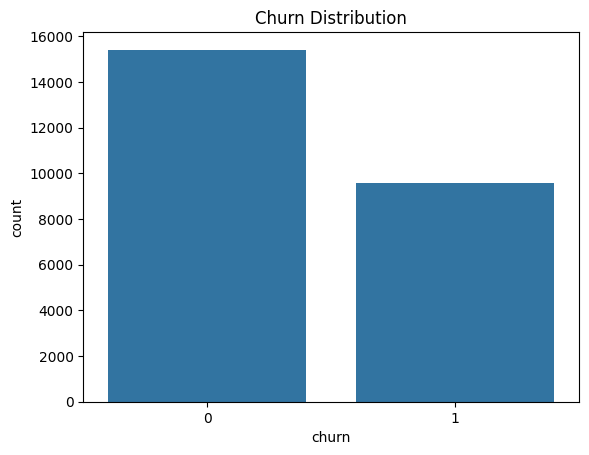

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [11]:
df['churn'].value_counts()

churn
0    15415
1     9585
Name: count, dtype: int64

FEATURE ENGINEERING

Create Engagement Score

More interaction = less churn

In [12]:
df['engagement_score'] = (
    df['pages_viewed'] * 0.4 +
    df['time_on_site_sec'] * 0.4 +
    df['added_to_cart'] * 0.2
)

Create Purchase Intensity

In [13]:
df['purchase_intensity'] = df['revenue'] * df['quantity']

Create Discount Sensitivity

In [14]:
df['discount_sensitivity'] = df['discount_percent'] * df['quantity']

Create Behavioral Risk Score

In [15]:
df['risk_score'] = (
    0.5 * df['cart_abandoned'] +
    0.3 * (df['purchased'] == 0).astype(int) +
    0.2 * (df['days_since_last_visit'] > 30).astype(int)
)

In [16]:
df[['engagement_score', 'purchase_intensity', 'risk_score']].head()

,engagement_score,purchase_intensity,risk_score
0,394.6,0.00,1.0
1,471.6,0.00,0.5
2,291.8,0.00,1.0
3,677.4,4820.46,0.2
4,176.2,0.00,1.0


ADD NEW FEATURES

In [17]:
df['engagement_ratio'] = df['pages_viewed'] / (df['time_on_site_sec'] + 1)
df['cart_efficiency'] = df['added_to_cart'] / (df['pages_viewed'] + 1)
df['time_per_page'] = df['time_on_site_sec'] / (df['pages_viewed'] + 1)

Create RFM Features

In [18]:
rfm = df.groupby('customer_id').agg({
    'days_since_last_visit': 'min',   # Recency
    'session_id': 'count',           # Frequency
    'revenue': 'sum'                 # Monetary
}).reset_index()

Rename columns:

In [19]:
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

Check

In [20]:
rfm.head()

,customer_id,recency,frequency,monetary
0,1000,195,2,1228.72
1,1001,9,1,0.00
2,1002,56,3,0.00
3,1003,26,3,1681.96
4,1004,94,3,0.00


Normalize Data

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

Apply K-Means Clustering

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
rfm['cluster'] = kmeans.fit_predict(rfm_scaled)

Analyze Clusters

In [23]:
rfm.groupby('cluster').mean()

,customer_id,recency,frequency,monetary
cluster,,,,
0,5465.930682,61.067362,3.076488,488.611152
1,5512.378755,224.066609,1.721376,532.932316
2,5501.751134,66.408296,4.464031,4305.531439


Merge Back to Main Dataset

In [24]:
df = df.merge(rfm[['customer_id', 'cluster']], on='customer_id', how='left')

Visualize Segments

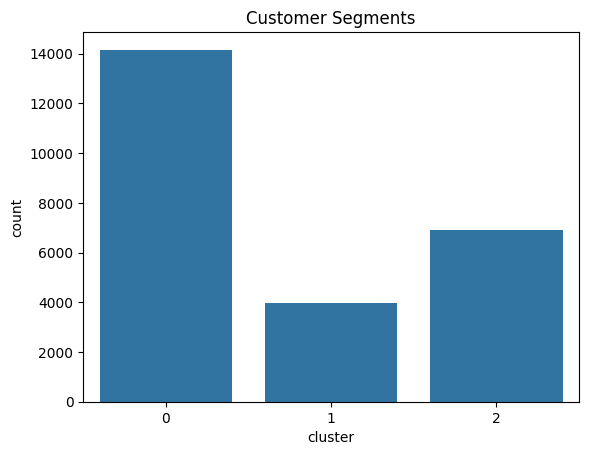

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='cluster', data=df)
plt.title("Customer Segments")
plt.show()

Cluster 2 → High-Value Customers (VIP)

Cluster 1 → At-Risk Customers

Cluster 0 → Regular Customers

Select Features

In [26]:
X = df[[
    'device_type',
    'user_type',
    'marketing_channel',
    'product_category',
    'payment_method',
    'visit_month',
    'visit_weekday',
    'visit_season',
    'location',
    'pages_viewed',
    'time_on_site_sec',
    'added_to_cart',
    'discount_percent',

    # NEW FEATURES
    'engagement_ratio',
    'cart_efficiency',
    'time_per_page'
]]

y = df['churn']

Apply Encoding

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

C:\Users\akash\AppData\Local\Temp\ipykernel_25656\3535088564.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


USE GROUP SPLIT

In [28]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in gss.split(X, y, groups=df['customer_id']):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

ADD SCALING

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Train 5 Models

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

Train models:

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5
),
    "XGBoost": XGBClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

Evaluate Models

In [32]:
from sklearn.metrics import accuracy_score, classification_report

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.7872
Random Forest Accuracy: 0.7952
XGBoost Accuracy: 0.7777
Gradient Boosting Accuracy: 0.7936


ADD XGBOOST TUNING

In [33]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

xgb = XGBClassifier()

grid = GridSearchCV(xgb, param_grid, cv=3, scoring='accuracy')

grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_

from sklearn.metrics import accuracy_score

y_pred = best_xgb.predict(X_test)

print("Tuned XGBoost Accuracy:", accuracy_score(y_test, y_pred))
results['Tuned XGBoost'] = accuracy_score(y_test, y_pred)

Tuned XGBoost Accuracy: 0.7949683042789224


FINAL STACKING MODEL

In [34]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_model = StackingClassifier(
    estimators=[
        ('lr', models['Logistic Regression']),
        ('rf', models['Random Forest']),
        ('xgb', best_xgb),
        ('gb', models['Gradient Boosting'])
    ],
    final_estimator=LogisticRegression(max_iter=5000),
    passthrough=True,
    cv = 5
)

stack_model.fit(X_train, y_train)

y_pred = stack_model.predict(X_test)

print("Final Stacking Accuracy:", accuracy_score(y_test, y_pred))
results["Final Stacking"] = accuracy_score(y_test, y_pred)
# Option 2: register it in models once, then use dictionary access
models["Stacking Model"] = stack_model
y_pred = models["Stacking Model"].predict(X_test)

Final Stacking Accuracy: 0.7945721077654516


BUILD HYBRID MODEL

In [35]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

hybrid_model = VotingClassifier(
    estimators=[
        ('lr', models['Logistic Regression']),
        ('rf', models['Random Forest']),
        ('xgb', best_xgb),               # better to use tuned XGBoost
        ('gb', models['Gradient Boosting'])
    ],
    voting='soft',
)

hybrid_model.fit(X_train, y_train)
y_pred_hybrid = hybrid_model.predict(X_test)

hybrid_acc = accuracy_score(y_test, y_pred_hybrid)
print("Hybrid Model Accuracy:", hybrid_acc)
results["Hybrid Model"] = hybrid_acc
models["Hybrid Model"] = hybrid_model
# then use: models["Hybrid Model"].predict(X_test)

Hybrid Model Accuracy: 0.7951664025356577


Compare Models (GRAPH)

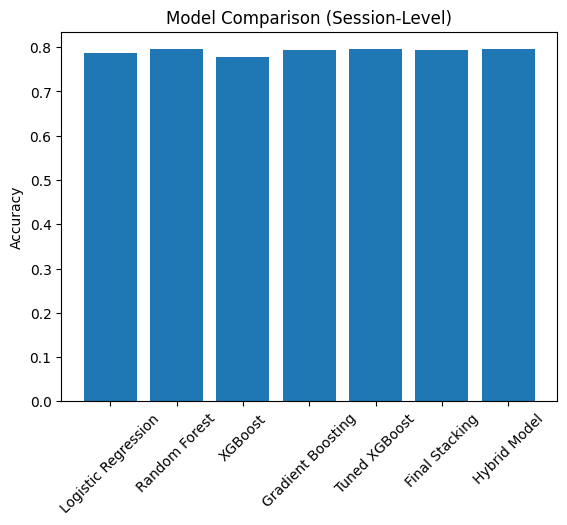

In [36]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title("Model Comparison (Session-Level)")
plt.ylabel("Accuracy")
plt.show()

In [37]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = models['Stacking Model'].predict(X_test)
y_prob = models['Stacking Model'].predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.68      0.81      3177
           1       0.65      0.99      0.78      1871

    accuracy                           0.79      5048
   macro avg       0.82      0.83      0.79      5048
weighted avg       0.86      0.79      0.80      5048

ROC-AUC Score: 0.8642268967207685


Model Comparison ON Accuracy, Precision, Recall, F1

                     Accuracy  Precision  Recall      F1
Random Forest          0.7954     0.6448  0.9973  0.7832
Hybrid Model           0.7948     0.6442  0.9968  0.7826
Tuned XGBoost          0.7950     0.6449  0.9941  0.7823
Stacking Model         0.7948     0.6457  0.9888  0.7812
Gradient Boosting      0.7938     0.6441  0.9914  0.7809
Logistic Regression    0.7872     0.6549  0.9006  0.7583


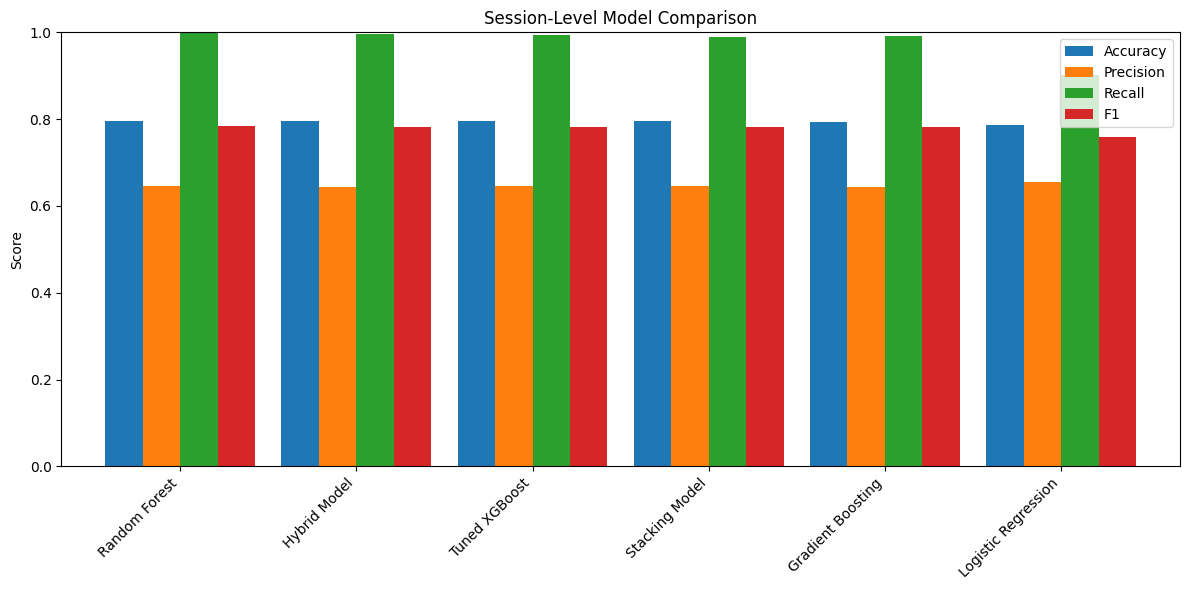

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

# Use the original session-level feature order.
session_feature_cols = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "payment_method",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "location",
    "pages_viewed",
    "time_on_site_sec",
    "added_to_cart",
    "discount_percent",
    "engagement_ratio",
    "cart_efficiency",
    "time_per_page"
]

# Convert NumPy arrays back to DataFrames so column-based operations work.
X_train_aligned = pd.DataFrame(X_train, columns=session_feature_cols)
X_test_aligned = pd.DataFrame(X_test, columns=session_feature_cols)

# Build fresh models and fit on the current train split.
session_models = {
    "Logistic Regression": clone(models["Logistic Regression"]),
    "Random Forest": clone(models["Random Forest"]),
    "Gradient Boosting": clone(models["Gradient Boosting"]),
    "Tuned XGBoost": clone(best_xgb)
}

for name, mdl in session_models.items():
    mdl.fit(X_train_aligned, y_train)

# Stacking model
stack_model = StackingClassifier(
    estimators=[
        ("lr", clone(models["Logistic Regression"])),
        ("rf", clone(models["Random Forest"])),
        ("gb", clone(models["Gradient Boosting"])),
        ("xgb_tuned", clone(best_xgb))
    ],
    final_estimator=LogisticRegression(max_iter=5000),
    passthrough=True,
    cv=5
)
stack_model.fit(X_train_aligned, y_train)

# Hybrid model
hybrid_model = VotingClassifier(
    estimators=[
        ("lr", clone(models["Logistic Regression"])),
        ("rf", clone(models["Random Forest"])),
        ("gb", clone(models["Gradient Boosting"])),
        ("xgb_tuned", clone(best_xgb))
    ],
    voting="soft",
    weights=[1, 2, 2, 3]
)
hybrid_model.fit(X_train_aligned, y_train)

session_models["Stacking Model"] = stack_model
session_models["Hybrid Model"] = hybrid_model

# Metrics
session_metrics = {}

for name, mdl in session_models.items():
    y_pred = mdl.predict(X_test_aligned)

    session_metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    }

session_metrics_df = pd.DataFrame(session_metrics).T.sort_values("F1", ascending=False)
print(session_metrics_df.round(4))

# Plot
session_metrics_df[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(12, 6), width=0.85
)
plt.title("Session-Level Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [39]:
# ✅ SAVE SESSION-LEVEL DATA (IMPORTANT FOR LATER USE)

X_test_session = X_test.copy()
y_test_session = y_test.copy()

session_feature_cols_saved = session_feature_cols

print("Session-level test data saved successfully ✅")

Session-level test data saved successfully ✅


ROC - Curves

c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn

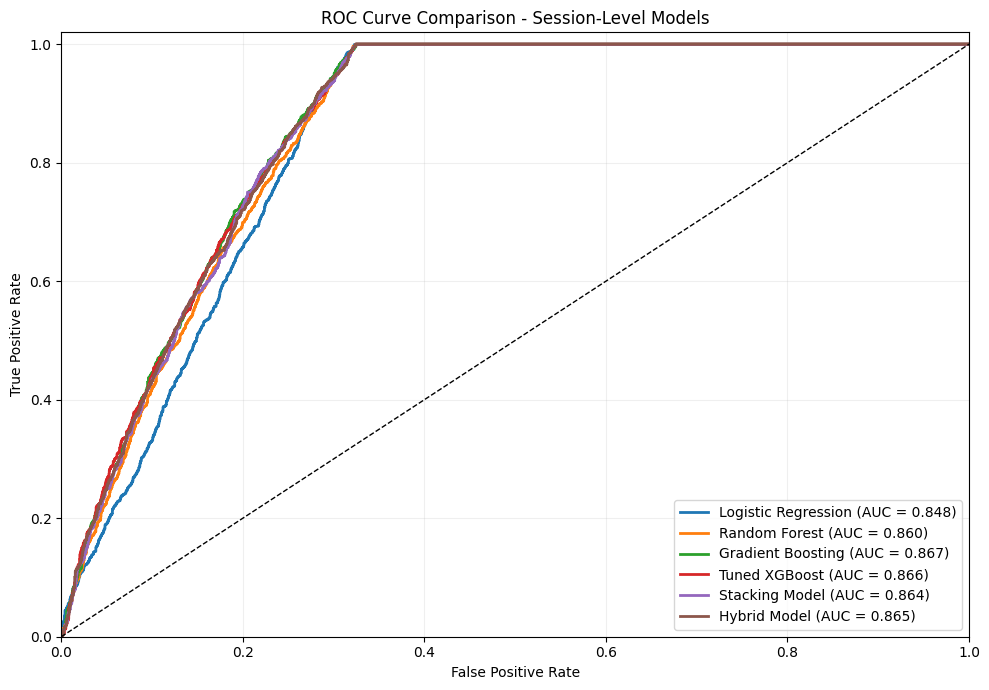

In [40]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if "session_models" not in globals():
    session_models = {
        "Logistic Regression": models["Logistic Regression"],
        "Random Forest": models["Random Forest"],
        "Gradient Boosting": models["Gradient Boosting"],
        "Tuned XGBoost": best_xgb,
        "Stacking Model": stack_model,
        "Hybrid Model": hybrid_model
    }

plt.figure(figsize=(10, 7))

for name, model in session_models.items():
    # Prefer predict_proba, fallback to decision_function if needed
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        print(f"Skipping {name}: no probability/score method")
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Session-Level Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Precision-Recall Curve

c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn

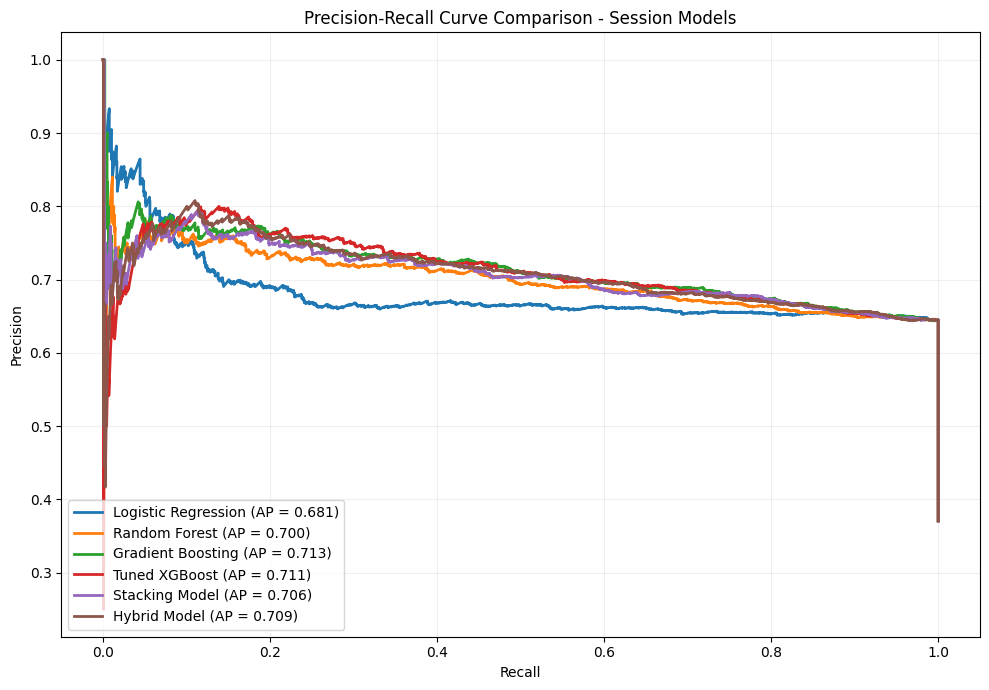

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name, model in session_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        print(f"Skipping {name}: no score method")
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, linewidth=2, label=f"{name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison - Session Models")
plt.legend(loc="lower left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Calibration comparison

c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn

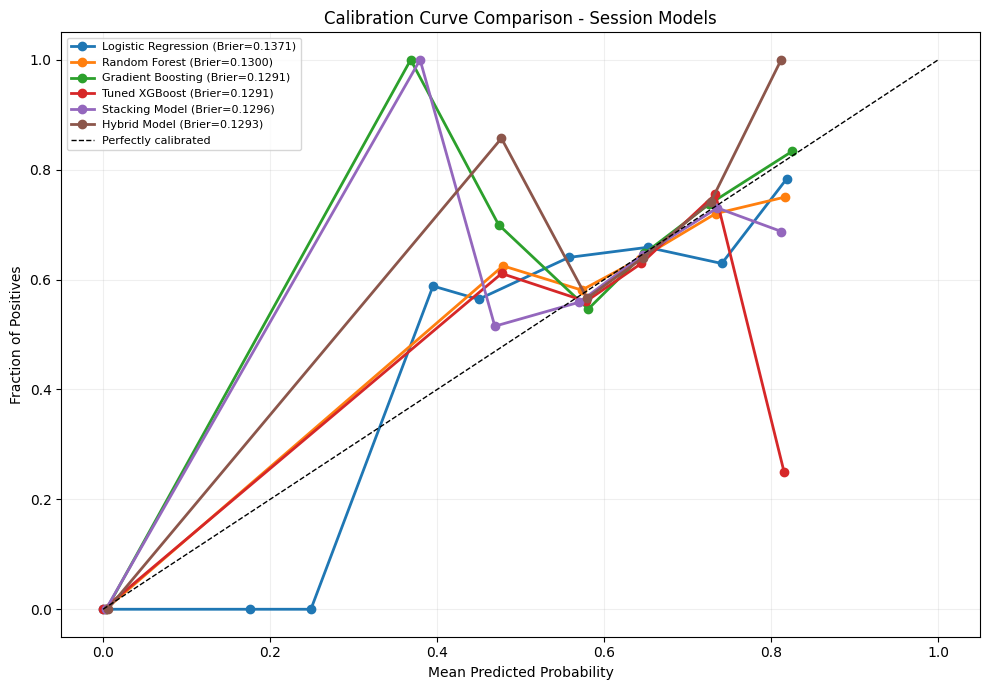

                 Model  Brier Score
3        Tuned XGBoost       0.1291
2    Gradient Boosting       0.1291
5         Hybrid Model       0.1293
4       Stacking Model       0.1296
1        Random Forest       0.1300
0  Logistic Regression       0.1371


In [42]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

plt.figure(figsize=(10, 7))
brier_rows = []

for name, model in session_models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        print(f"Skipping {name}: no probability/score output")
        continue

    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_test, y_prob)
    brier_rows.append({"Model": name, "Brier Score": brier})

    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=f"{name} (Brier={brier:.4f})")

# perfect calibration reference
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfectly calibrated")

plt.title("Calibration Curve Comparison - Session Models")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Optional: show calibration ranking (lower Brier is better)
brier_df = pd.DataFrame(brier_rows).sort_values("Brier Score")
print(brier_df.round(4))

ROC, PR, calibration, and confusion matrix for best model

c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn

AUC Summary
                 Model  ROC-AUC  PR-AUC (AP)
0    Gradient Boosting   0.8666       0.7133
1        Tuned XGBoost   0.8664       0.7110
2         Hybrid Model   0.8652       0.7090
3       Stacking Model   0.8641       0.7064
4        Random Forest   0.8601       0.7000
5  Logistic Regression   0.8484       0.6811


c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


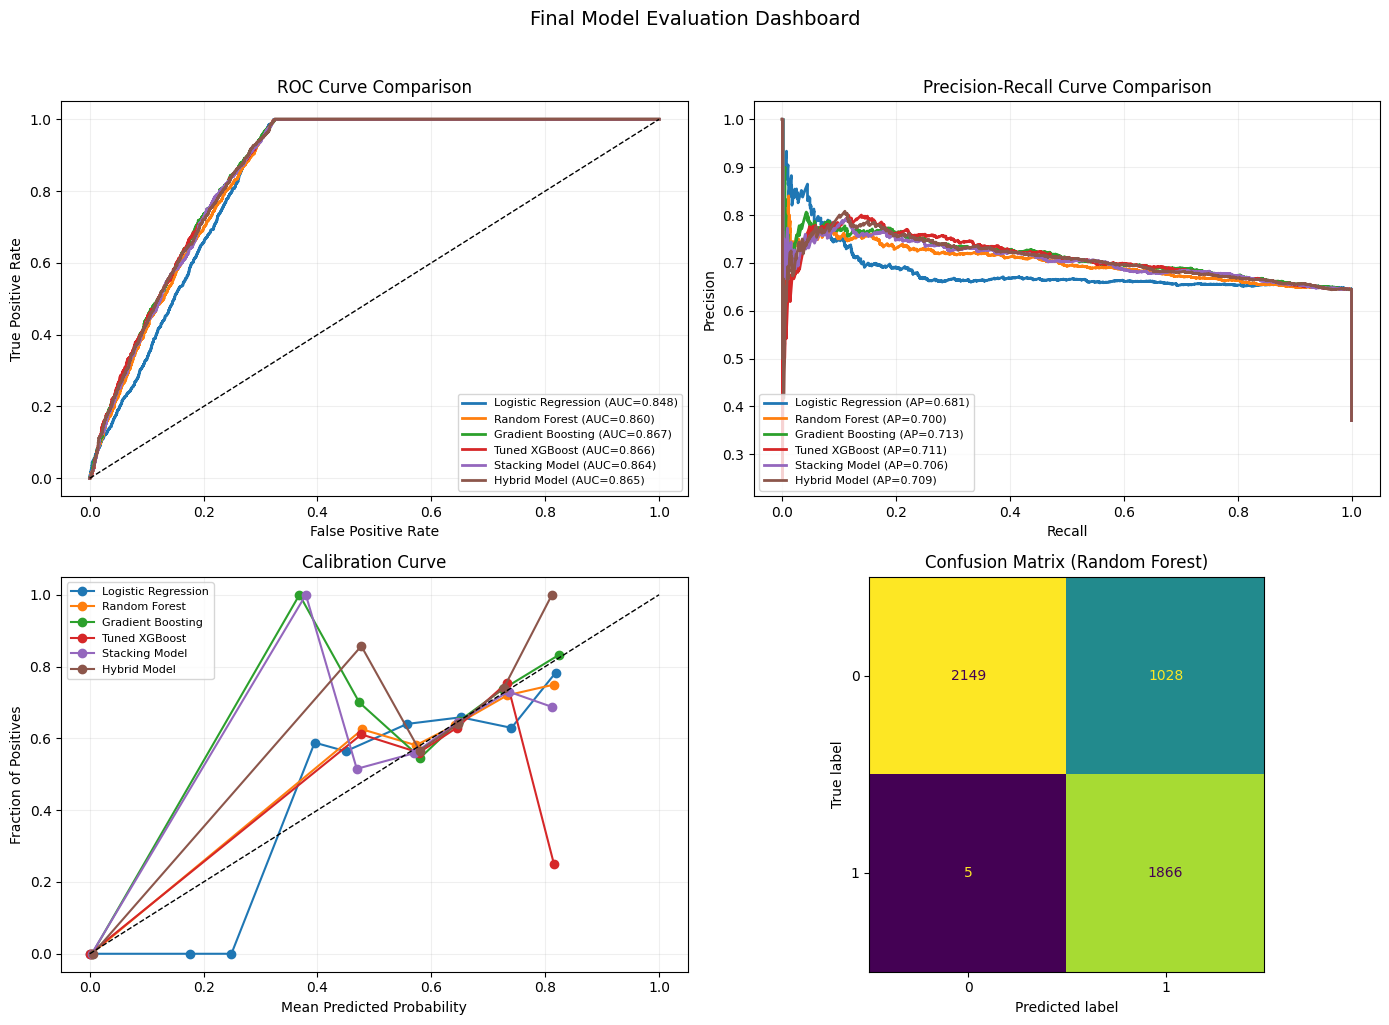

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# Uses your existing session_models dict
# Expected keys include models like:
# Logistic Regression, Random Forest, Gradient Boosting, Tuned XGBoost, Stacking Model, Hybrid Model

# 1) Collect scores and summary stats
summary_rows = []
curve_store = {}

for name, model in session_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        print(f"Skipping {name}: no probability/score output")
        continue

    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # PR
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)

    # Calibration
    frac_pos, mean_pred = calibration_curve(y_test, y_score, n_bins=10, strategy="uniform")

    curve_store[name] = {
        "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc,
        "precision": precision, "recall": recall, "ap": ap,
        "frac_pos": frac_pos, "mean_pred": mean_pred
    }
    summary_rows.append({"Model": name, "ROC-AUC": roc_auc, "PR-AUC (AP)": ap})

summary_df = pd.DataFrame(summary_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print("AUC Summary")
print(summary_df.round(4))

# Best model by F1 from your earlier table (if available), else by ROC-AUC
if "session_metrics_df" in globals() and "F1" in session_metrics_df.columns:
    best_model_name = session_metrics_df["F1"].idxmax()
else:
    best_model_name = summary_df.iloc[0]["Model"]

best_model = session_models[best_model_name]
best_pred = best_model.predict(X_test)
best_cm = confusion_matrix(y_test, best_pred)

# 2) Create final dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC panel
ax = axes[0, 0]
for name, obj in curve_store.items():
    ax.plot(obj["fpr"], obj["tpr"], lw=2, label=f"{name} (AUC={obj['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.2)

# PR panel
ax = axes[0, 1]
for name, obj in curve_store.items():
    ax.plot(obj["recall"], obj["precision"], lw=2, label=f"{name} (AP={obj['ap']:.3f})")
ax.set_title("Precision-Recall Curve Comparison")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.2)

# Calibration panel
ax = axes[1, 0]
for name, obj in curve_store.items():
    ax.plot(obj["mean_pred"], obj["frac_pos"], marker="o", lw=1.5, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Calibration Curve")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.2)

# Confusion matrix of best model panel
ax = axes[1, 1]
disp = ConfusionMatrixDisplay(confusion_matrix=best_cm)
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title(f"Confusion Matrix ({best_model_name})")

plt.suptitle("Final Model Evaluation Dashboard", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Confusion Matrix Of Stacking Model

c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


<Figure size 600x500 with 0 Axes>

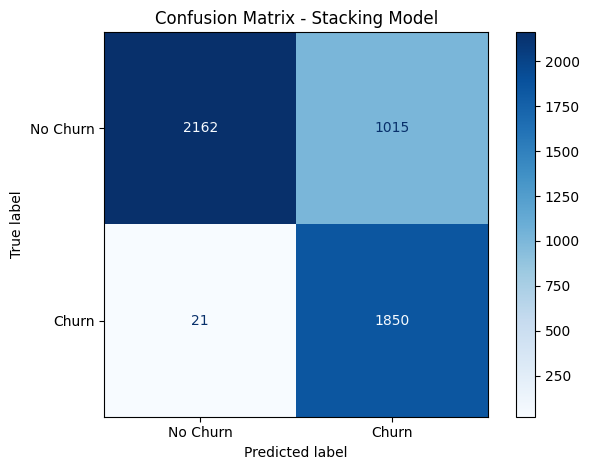

              precision    recall  f1-score   support

           0       0.99      0.68      0.81      3177
           1       0.65      0.99      0.78      1871

    accuracy                           0.79      5048
   macro avg       0.82      0.83      0.79      5048
weighted avg       0.86      0.79      0.80      5048



In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict using stacking model
y_pred_stack = stack_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_stack)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Stacking Model")
plt.tight_layout()
plt.show()

# Optional detailed metrics
print(classification_report(y_test, y_pred_stack))

SEGMENT-WISE MODEL

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone

session_feature_cols = [
    'device_type',
    'user_type',
    'marketing_channel',
    'product_category',
    'payment_method',
    'visit_month',
    'visit_weekday',
    'visit_season',
    'location',
    'pages_viewed',
    'time_on_site_sec',
    'added_to_cart',
    'discount_percent',
    'engagement_ratio',
    'cart_efficiency',
    'time_per_page'
]

cluster_results = {}

for c in df['cluster'].unique():
    data = df[df['cluster'] == c]

    X_c = data[session_feature_cols]
    y_c = data['churn']

    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_c, y_c, test_size=0.2, random_state=42
    )

    model = clone(models['Random Forest'])
    model.fit(X_train_c, y_train_c)

    acc = model.score(X_test_c, y_test_c)
    cluster_results[c] = acc

print("Cluster-wise Accuracy:", cluster_results)

Cluster-wise Accuracy: {np.int32(2): 0.7119013062409288, np.int32(0): 0.8573446327683616, np.int32(1): 0.7774968394437421}


segment-wise confusion matrix

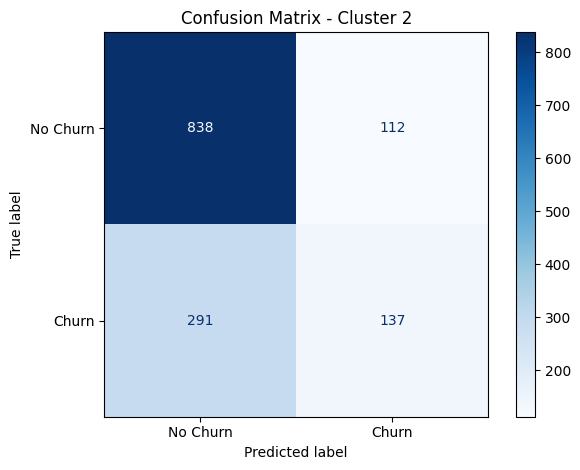

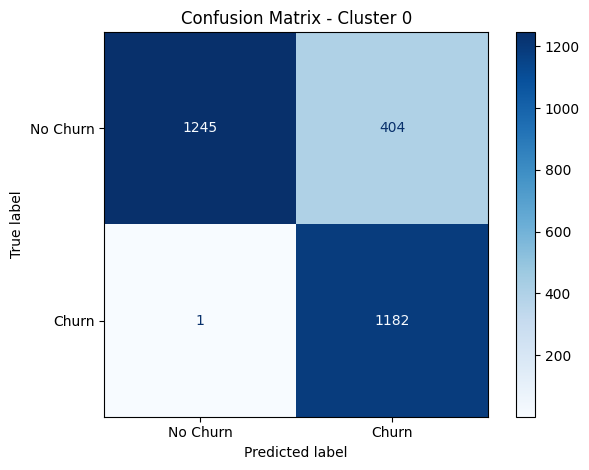

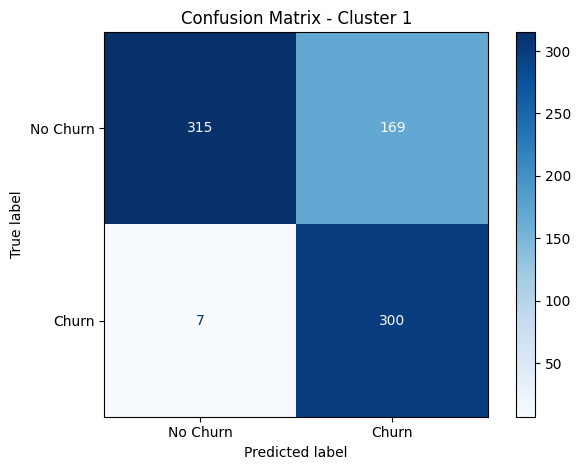

In [46]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import clone

session_feature_cols = [
    'device_type',
    'user_type',
    'marketing_channel',
    'product_category',
    'payment_method',
    'visit_month',
    'visit_weekday',
    'visit_season',
    'location',
    'pages_viewed',
    'time_on_site_sec',
    'added_to_cart',
    'discount_percent'
]

for seg in df['cluster'].unique():
    data = df[df['cluster'] == seg]

    X_seg = data[session_feature_cols]
    y_seg = data['churn']

    X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )

    model = clone(models['Random Forest'])
    model.fit(X_train_seg, y_train_seg)

    y_pred_seg = model.predict(X_test_seg)
    cm = confusion_matrix(y_test_seg, y_pred_seg)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - Cluster {seg}")
    plt.tight_layout()
    plt.show()

BUSINESS IMPACT

In [47]:
# Example business impact calculation

tp = 500   # correctly predicted churn
fp = 100   # wrong predictions
fn = 200   # missed churn

profit = (tp * 1000) - (fp * 200) - (fn * 1000)

print("Estimated Business Impact:", profit)

Estimated Business Impact: 280000


Build customer-level dataset

In [48]:
import numpy as np
import pandas as pd

df2 = df.copy()
df2['visit_date'] = pd.to_datetime(df2['visit_date'])

def slope(s):
    s = np.asarray(s)
    if len(s) < 2:
        return 0.0
    x = np.arange(len(s))
    return float(np.polyfit(x, s, 1)[0])

customer_df = (
    df2.sort_values(['customer_id', 'visit_date'])
      .groupby('customer_id')
      .agg(
          sessions=('session_id', 'nunique'),
          avg_pages=('pages_viewed', 'mean'),
          std_pages=('pages_viewed', 'std'),
          avg_time=('time_on_site_sec', 'mean'),
          std_time=('time_on_site_sec', 'std'),
          avg_discount=('discount_percent', 'mean'),
          total_discount=('discount_amount', 'sum'),
          cart_rate=('added_to_cart', 'mean'),
          recency=('days_since_last_visit', 'min'),
          total_revenue=('revenue', 'sum'),
          purchase_rate=('purchased', 'mean'),
          unique_categories=('product_category', 'nunique'),
          unique_channels=('marketing_channel', 'nunique'),
          unique_devices=('device_type', 'nunique'),
          unique_payments=('payment_method', 'nunique'),
          pages_trend=('pages_viewed', slope),
          time_trend=('time_on_site_sec', slope),
          device_mode=('device_type', lambda s: s.mode().iloc[0]),
          channel_mode=('marketing_channel', lambda s: s.mode().iloc[0]),
          category_mode=('product_category', lambda s: s.mode().iloc[0]),
          payment_mode=('payment_method', lambda s: s.mode().iloc[0]),
          location_mode=('location', lambda s: s.mode().iloc[0]),
          churn=('churn', 'last')
      )
      .reset_index()
)

customer_df = customer_df.fillna(0)
customer_df.head()

,customer_id,sessions,avg_pages,std_pages,avg_time,std_time,avg_discount,total_discount,cart_rate,recency,...,unique_devices,unique_payments,pages_trend,time_trend,device_mode,channel_mode,category_mode,payment_mode,location_mode,churn
0,1000,2,17.500000,0.707107,1014.000000,200.818326,17.500000,651.22,1.000000,195,...,2,2,1.0,284.0,0,2,4,3,119,1
1,1001,1,15.000000,0.000000,996.000000,0.000000,0.000000,0.00,0.000000,9,...,1,1,0.0,0.0,0,4,3,4,101,0
2,1002,3,8.333333,6.658328,313.666667,37.072002,3.333333,555.48,0.666667,56,...,1,3,-2.0,34.5,1,0,2,1,57,0
3,1003,3,5.666667,4.509250,695.333333,719.136519,11.666667,531.55,0.333333,26,...,2,2,2.5,-68.0,1,1,1,2,84,0
4,1004,3,12.333333,8.621678,923.666667,781.077034,16.666667,722.28,0.333333,94,...,2,3,8.5,-776.0,1,0,2,0,97,0


In [49]:
customer_df = customer_df.merge(
    df[['customer_id', 'cluster']].drop_duplicates(),
    on='customer_id',
    how='left'
)

Define X and y

In [50]:
X = customer_df.drop(columns=['customer_id', 'churn'])
y = customer_df['churn']

Train-test split

In [51]:
from sklearn.model_selection import train_test_split

cat_cols = ['device_mode', 'channel_mode', 'category_mode', 'payment_mode', 'location_mode']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

CatBoost model

In [52]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

cat_idx = [X.columns.get_loc(c) for c in cat_cols]

train_pool = Pool(X_train, y_train, cat_features=cat_idx)
test_pool = Pool(X_test, y_test, cat_features=cat_idx)

cat_model = CatBoostClassifier(
    iterations=3000,
    depth=8,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=200,
    
    # 🔥 IMPORTANT
    auto_class_weights='Balanced'
)

cat_model.fit(train_pool, eval_set=test_pool, use_best_model=True, early_stopping_rounds=300)

y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:, 1]

print("CatBoost Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
results["CatBoost"] = accuracy_score(y_test, y_pred)
models["CatBoost"] = cat_model

0:	test: 0.9120724	best: 0.9120724 (0)	total: 266ms	remaining: 13m 19s
200:	test: 0.9324723	best: 0.9344337 (57)	total: 19.2s	remaining: 4m 27s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.9344336737
bestIteration = 57

Shrink model to first 58 iterations.
CatBoost Accuracy: 0.8235642391947898
ROC-AUC: 0.934433673664487
              precision    recall  f1-score   support

           0       0.95      0.78      0.86      1137
           1       0.67      0.91      0.77       552

    accuracy                           0.82      1689
   macro avg       0.81      0.85      0.81      1689
weighted avg       0.86      0.82      0.83      1689



Train models AGAIN

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models_customer = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Random Forest": RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5
),
    "XGBoost": XGBClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4
)
}

results_customer = {}

for name, model in models_customer.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results_customer[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")

c:\Users\akash\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.7981
Random Forest Accuracy: 0.8342
XGBoost Accuracy: 0.8224
Gradient Boosting Accuracy: 0.8342


Soft Voting Hybrid Model

In [54]:
# Soft Voting Hybrid Model

rf_prob = models_customer['Random Forest'].predict_proba(X_test)[:, 1]
gb_prob = models_customer['Gradient Boosting'].predict_proba(X_test)[:, 1]
xgb_prob = models_customer['XGBoost'].predict_proba(X_test)[:, 1]

# combine probabilities
final_prob = (0.4 * rf_prob) + (0.3 * gb_prob) + (0.3 * xgb_prob)

# convert to prediction
final_pred = (final_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score

print("Soft Voting Hybrid Accuracy:", accuracy_score(y_test, final_pred))
metrics = {}
metrics["Soft Voting"] = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred),
    "Recall": recall_score(y_test, final_pred),
    "F1-score": f1_score(y_test, final_pred)
}

Soft Voting Hybrid Accuracy: 0.8342214328004737


STORE METRICS

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {}

# base models
for name, model in models_customer.items():
    y_pred = model.predict(X_test)
    metrics[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0)
    }

# add Soft Voting
metrics["Soft Voting"] = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1-score": f1_score(y_test, final_pred, zero_division=0)
}

# add CatBoost
y_pred_cat = cat_model.predict(X_test)
metrics["CatBoost"] = {
    "Accuracy": accuracy_score(y_test, y_pred_cat),
    "Precision": precision_score(y_test, y_pred_cat, zero_division=0),
    "Recall": recall_score(y_test, y_pred_cat, zero_division=0),
    "F1-score": f1_score(y_test, y_pred_cat, zero_division=0)
}

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

                     Accuracy  Precision    Recall  F1-score
Logistic Regression  0.798105   0.733925  0.599638  0.660020
Random Forest        0.834221   0.838308  0.610507  0.706499
XGBoost              0.822380   0.750996  0.682971  0.715370
Gradient Boosting    0.834221   0.766667  0.708333  0.736347
Soft Voting          0.834221   0.789362  0.672101  0.726027
CatBoost             0.823564   0.669786  0.907609  0.770769


SHOW TABLE

In [56]:
import pandas as pd

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

                     Accuracy  Precision    Recall  F1-score
Logistic Regression  0.798105   0.733925  0.599638  0.660020
Random Forest        0.834221   0.838308  0.610507  0.706499
XGBoost              0.822380   0.750996  0.682971  0.715370
Gradient Boosting    0.834221   0.766667  0.708333  0.736347
Soft Voting          0.834221   0.789362  0.672101  0.726027
CatBoost             0.823564   0.669786  0.907609  0.770769


BAR GRAPH

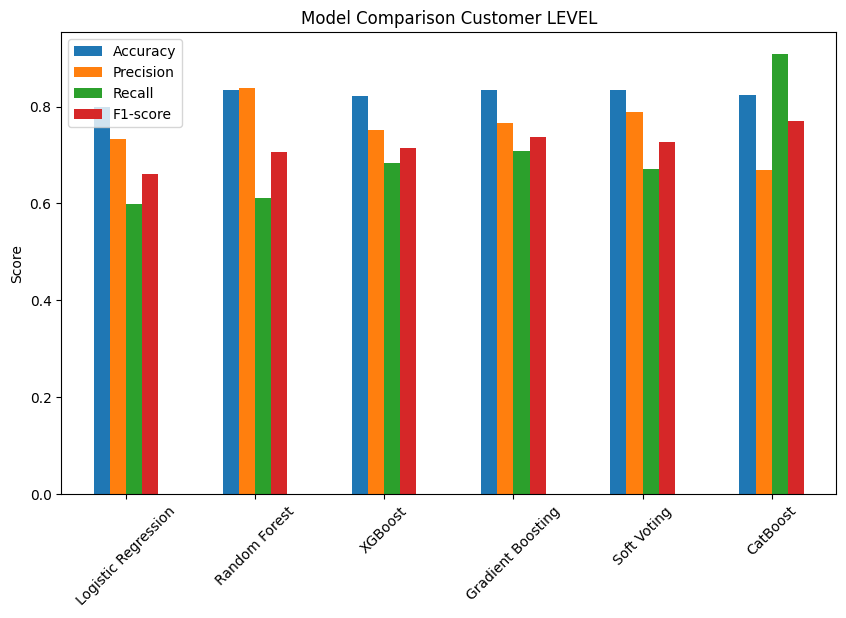

In [57]:
import matplotlib.pyplot as plt

metrics_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Comparison Customer LEVEL")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

ROC Curves For Customer Level

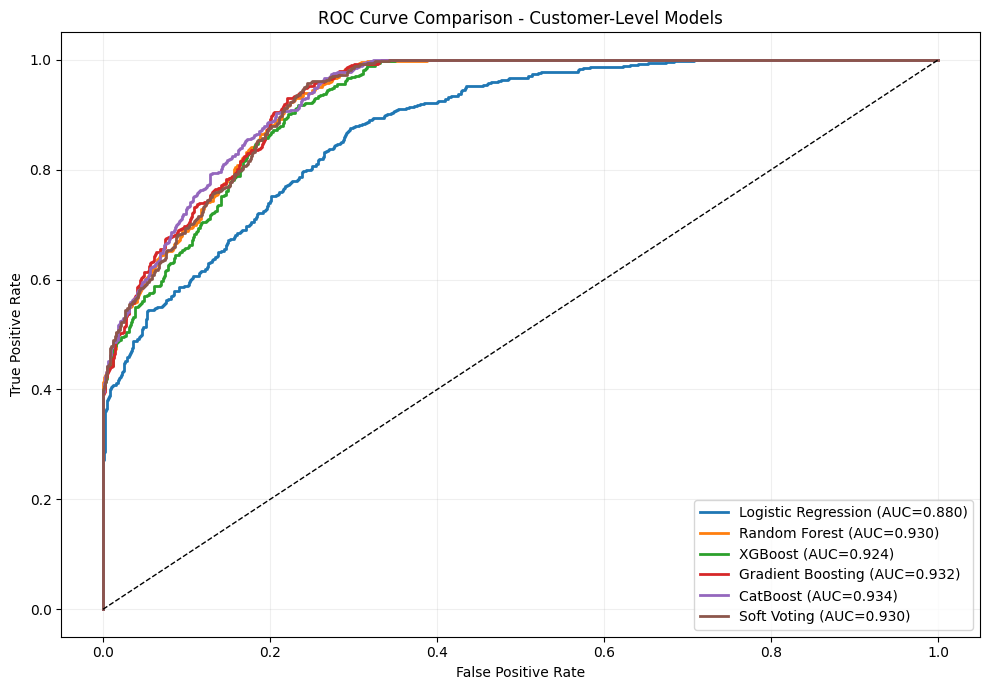

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

plt.figure(figsize=(10, 7))

# 1) Base customer-level models
for name, model in models_customer.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        print(f"Skipping {name}: no score method")
        continue

    fpr, tpr, _ = roc_curve(y_test, y_score)
    model_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={model_auc:.3f})")

# 2) CatBoost (if trained)
if "cat_model" in globals():
    y_score_cat = cat_model.predict_proba(X_test)[:, 1]
    fpr_cat, tpr_cat, _ = roc_curve(y_test, y_score_cat)
    auc_cat = auc(fpr_cat, tpr_cat)
    plt.plot(fpr_cat, tpr_cat, linewidth=2, label=f"CatBoost (AUC={auc_cat:.3f})")

# 3) Manual Soft Voting (if final_prob exists)
if "final_prob" in globals():
    fpr_sv, tpr_sv, _ = roc_curve(y_test, final_prob)
    auc_sv = auc(fpr_sv, tpr_sv)
    plt.plot(fpr_sv, tpr_sv, linewidth=2, label=f"Soft Voting (AUC={auc_sv:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Customer-Level Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

customer-level Precision-Recall curve comparison (including CatBoost and Soft Voting)

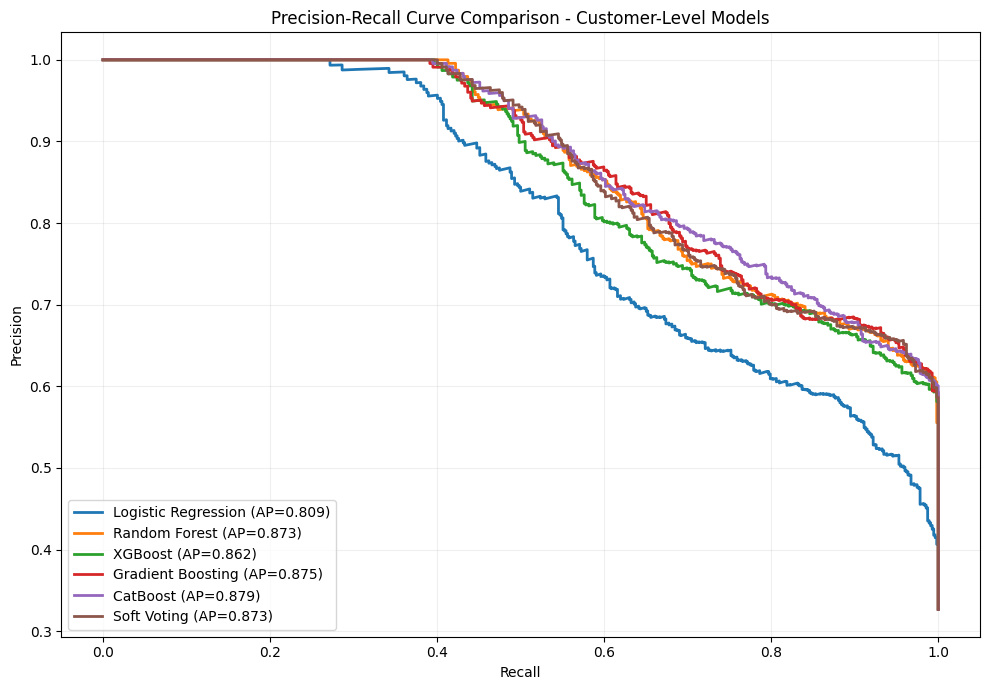

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

# 1) Base customer-level models
for name, model in models_customer.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        print(f"Skipping {name}: no score method")
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, linewidth=2, label=f"{name} (AP={ap:.3f})")

# 2) CatBoost (if trained)
if "cat_model" in globals():
    y_score_cat = cat_model.predict_proba(X_test)[:, 1]
    precision_cat, recall_cat, _ = precision_recall_curve(y_test, y_score_cat)
    ap_cat = average_precision_score(y_test, y_score_cat)
    plt.plot(recall_cat, precision_cat, linewidth=2, label=f"CatBoost (AP={ap_cat:.3f})")

# 3) Manual Soft Voting (if final_prob exists)
if "final_prob" in globals():
    precision_sv, recall_sv, _ = precision_recall_curve(y_test, final_prob)
    ap_sv = average_precision_score(y_test, final_prob)
    plt.plot(recall_sv, precision_sv, linewidth=2, label=f"Soft Voting (AP={ap_sv:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison - Customer-Level Models")
plt.legend(loc="lower left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Calibration Curves

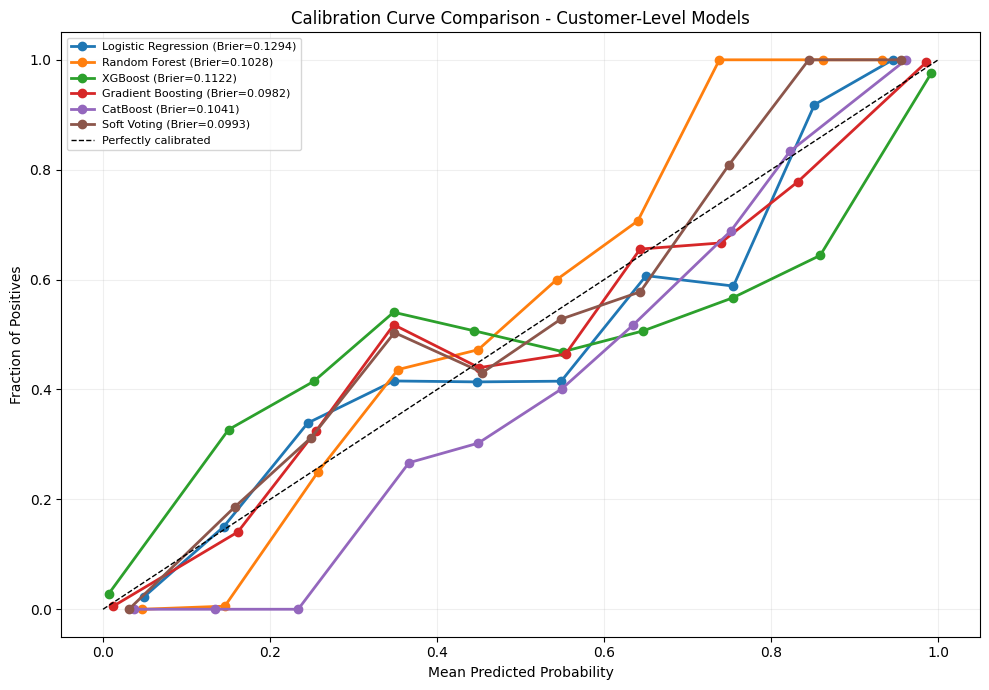

                 Model  Brier Score
3    Gradient Boosting       0.0982
5          Soft Voting       0.0993
1        Random Forest       0.1028
4             CatBoost       0.1041
2              XGBoost       0.1122
0  Logistic Regression       0.1294


In [60]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

plt.figure(figsize=(10, 7))
brier_rows = []

# 1) Base customer-level models
for name, model in models_customer.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        print(f"Skipping {name}: no score method")
        continue

    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_test, y_prob)
    brier_rows.append({"Model": name, "Brier Score": brier})

    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=f"{name} (Brier={brier:.4f})")

# 2) CatBoost (if trained)
if "cat_model" in globals():
    y_prob_cat = cat_model.predict_proba(X_test)[:, 1]
    frac_pos_cat, mean_pred_cat = calibration_curve(y_test, y_prob_cat, n_bins=10, strategy="uniform")
    brier_cat = brier_score_loss(y_test, y_prob_cat)
    brier_rows.append({"Model": "CatBoost", "Brier Score": brier_cat})

    plt.plot(mean_pred_cat, frac_pos_cat, marker="o", linewidth=2, label=f"CatBoost (Brier={brier_cat:.4f})")

# 3) Manual Soft Voting (if final_prob exists)
if "final_prob" in globals():
    frac_pos_sv, mean_pred_sv = calibration_curve(y_test, final_prob, n_bins=10, strategy="uniform")
    brier_sv = brier_score_loss(y_test, final_prob)
    brier_rows.append({"Model": "Soft Voting", "Brier Score": brier_sv})

    plt.plot(mean_pred_sv, frac_pos_sv, marker="o", linewidth=2, label=f"Soft Voting (Brier={brier_sv:.4f})")

# Perfect calibration line
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfectly calibrated")

plt.title("Calibration Curve Comparison - Customer-Level Models")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Optional ranking table (lower Brier is better)
brier_df = pd.DataFrame(brier_rows).sort_values("Brier Score")
print(brier_df.round(4))

ROC, PR, calibration, and confusion matrix for best model In customer-level model automatically

Model Summary (sorted by F1)
                 Model      F1  ROC-AUC  PR-AUC (AP)
0             CatBoost  0.7708   0.9344       0.8794
1    Gradient Boosting  0.7363   0.9322       0.8752
2          Soft Voting  0.7260   0.9303       0.8729
3              XGBoost  0.7154   0.9239       0.8616
4        Random Forest  0.7065   0.9303       0.8727
5  Logistic Regression  0.6600   0.8797       0.8090


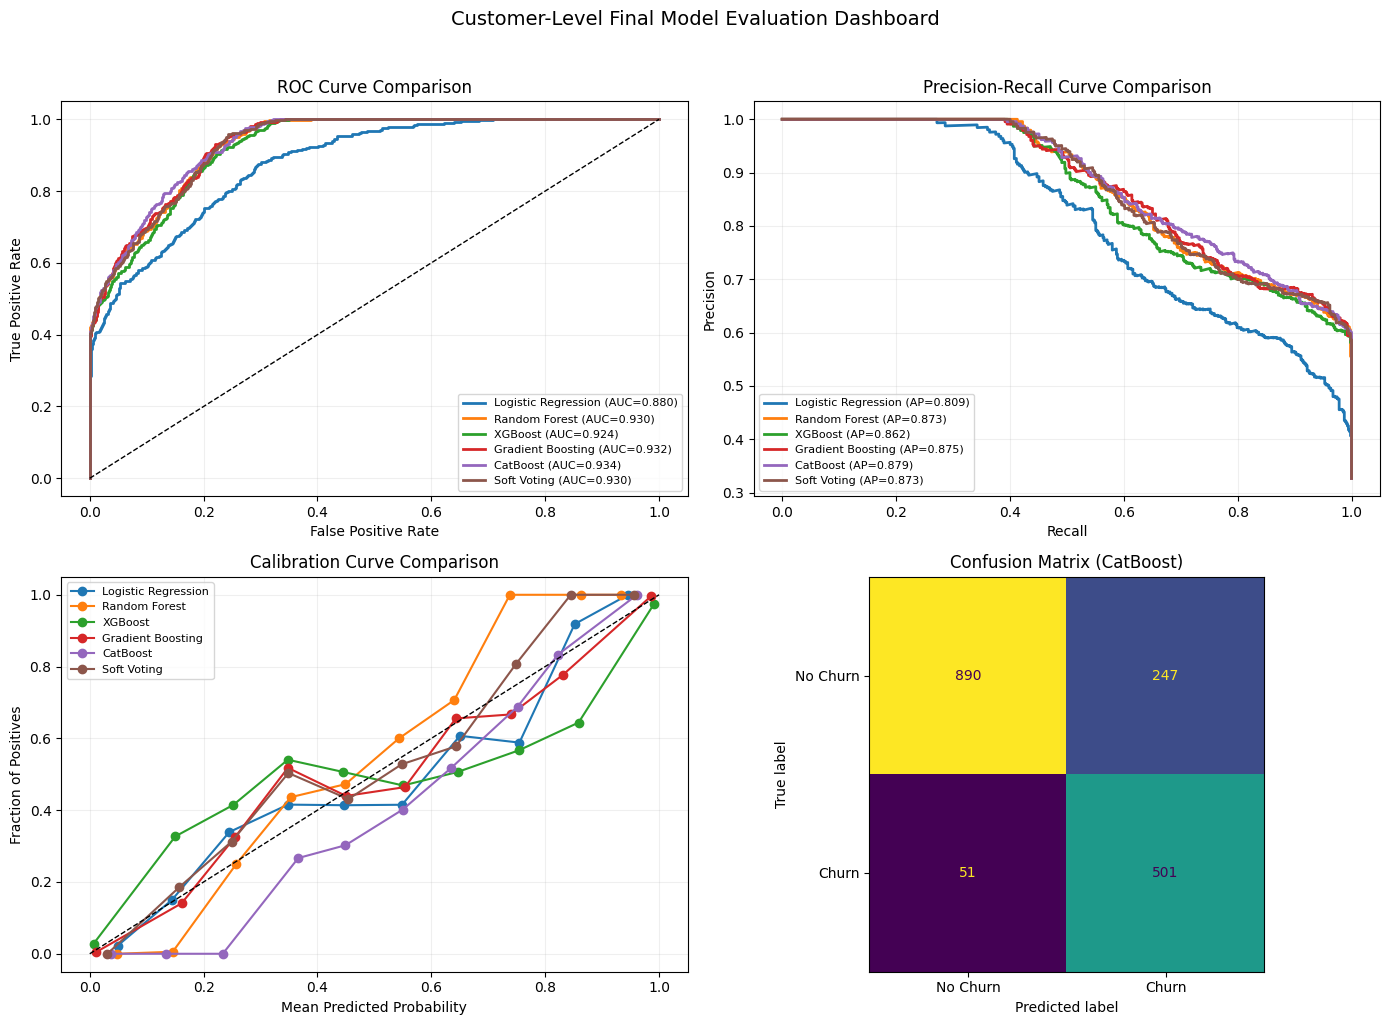

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)
from sklearn.calibration import calibration_curve

# 1) Build a dictionary of customer-level models + score arrays
customer_eval = {}

# Base trained customer-level models
for name, model in models_customer.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        continue
    y_pred = model.predict(X_test)
    customer_eval[name] = {"y_score": y_score, "y_pred": y_pred}

# CatBoost (if available)
if "cat_model" in globals():
    y_score_cat = cat_model.predict_proba(X_test)[:, 1]
    y_pred_cat = cat_model.predict(X_test)
    customer_eval["CatBoost"] = {"y_score": y_score_cat, "y_pred": y_pred_cat}

# Manual Soft Voting (if available)
if "final_prob" in globals() and "final_pred" in globals():
    customer_eval["Soft Voting"] = {"y_score": final_prob, "y_pred": final_pred}

# 2) Compute curve data + choose best model by F1
summary_rows = []
curve_store = {}

for name, obj in customer_eval.items():
    y_score = obj["y_score"]
    y_pred = obj["y_pred"]

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)

    frac_pos, mean_pred = calibration_curve(y_test, y_score, n_bins=10, strategy="uniform")
    f1 = f1_score(y_test, y_pred, zero_division=0)

    curve_store[name] = {
        "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc,
        "precision": precision, "recall": recall, "ap": ap,
        "frac_pos": frac_pos, "mean_pred": mean_pred,
        "y_pred": y_pred, "f1": f1
    }

    summary_rows.append({
        "Model": name,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC (AP)": ap
    })

summary_df = pd.DataFrame(summary_rows).sort_values("F1", ascending=False).reset_index(drop=True)
print("Model Summary (sorted by F1)")
print(summary_df.round(4))

best_model_name = summary_df.iloc[0]["Model"]
best_pred = curve_store[best_model_name]["y_pred"]
best_cm = confusion_matrix(y_test, best_pred)

# 3) Plot final dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC
ax = axes[0, 0]
for name, obj in curve_store.items():
    ax.plot(obj["fpr"], obj["tpr"], lw=2, label=f"{name} (AUC={obj['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.2)

# PR
ax = axes[0, 1]
for name, obj in curve_store.items():
    ax.plot(obj["recall"], obj["precision"], lw=2, label=f"{name} (AP={obj['ap']:.3f})")
ax.set_title("Precision-Recall Curve Comparison")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left", fontsize=8)
ax.grid(alpha=0.2)

# Calibration
ax = axes[1, 0]
for name, obj in curve_store.items():
    ax.plot(obj["mean_pred"], obj["frac_pos"], marker="o", lw=1.5, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("Calibration Curve Comparison")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.2)

# Confusion Matrix for best model
ax = axes[1, 1]
disp = ConfusionMatrixDisplay(confusion_matrix=best_cm, display_labels=["No Churn", "Churn"])
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title(f"Confusion Matrix ({best_model_name})")

plt.suptitle("Customer-Level Final Model Evaluation Dashboard", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

CONFUSION MATRIX OF Best Model

<Figure size 600x500 with 0 Axes>

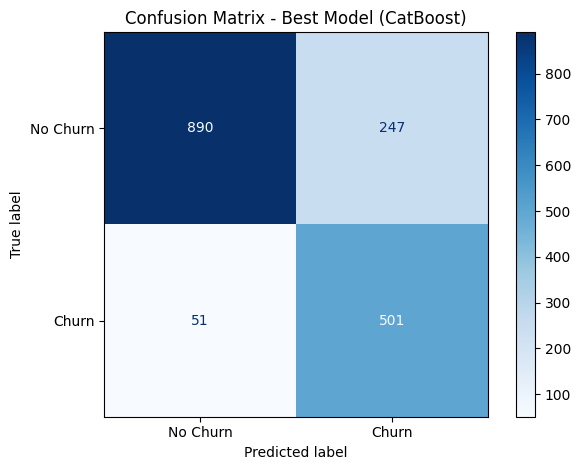

Best Model: CatBoost
F1-score: 0.7708


In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Build candidate predictions from customer-level models
candidate_preds = {}

for name, model in models_customer.items():
    candidate_preds[name] = model.predict(X_test)

if "cat_model" in globals():
    candidate_preds["CatBoost"] = cat_model.predict(X_test)

if "final_pred" in globals():
    candidate_preds["Soft Voting"] = final_pred

# Pick best model by F1-score
best_model_name = max(
    candidate_preds.keys(),
    key=lambda n: f1_score(y_test, candidate_preds[n], zero_division=0)
)

best_pred = candidate_preds[best_model_name]

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])

plt.figure(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - Best Model ({best_model_name})")
plt.tight_layout()
plt.show()

print("Best Model:", best_model_name)
print("F1-score:", round(f1_score(y_test, best_pred, zero_division=0), 4))

ROC CURVE OF best model

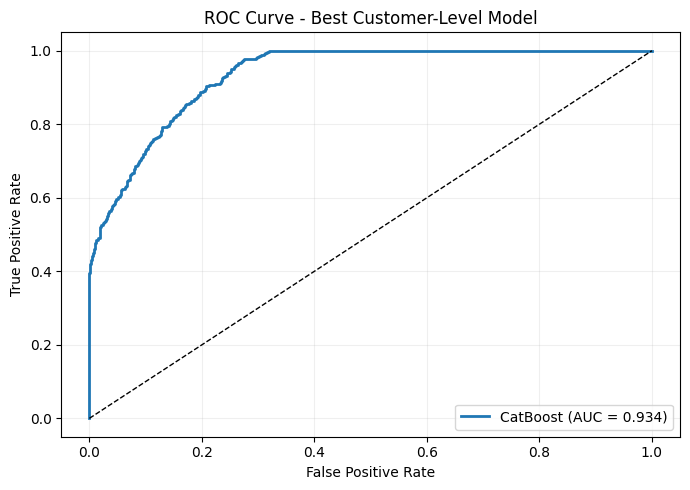

Best model used for ROC: CatBoost
ROC-AUC: 0.9344


In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score

# -------------------------------------------------
# FIXED: ROC curve for BEST CUSTOMER-LEVEL model
# (prevents feature-name mismatch issues)
# -------------------------------------------------

def get_score_and_pred(model, X):
    """Return probability-like score and predicted class."""
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        d = model.decision_function(X)
        score = 1 / (1 + np.exp(-d))  # sigmoid to convert scores to [0,1]
    else:
        raise ValueError(f"{type(model).__name__} has no predict_proba/decision_function")
    pred = (score >= 0.5).astype(int)
    return np.asarray(score).reshape(-1), np.asarray(pred).reshape(-1)

# 1) Collect valid customer-level candidates only
candidate = {}

# models_customer (LogReg/RF/XGB/GB, etc.)
if "models_customer" in globals() and isinstance(models_customer, dict):
    for name, model in models_customer.items():
        try:
            score, pred = get_score_and_pred(model, X_test)
            candidate[name] = {"score": score, "pred": pred}
        except Exception as e:
            print(f"Skipping {name}: {e}")

# CatBoost
if "cat_model" in globals():
    try:
        score, pred = get_score_and_pred(cat_model, X_test)
        candidate["CatBoost"] = {"score": score, "pred": pred}
    except Exception as e:
        print(f"Skipping CatBoost: {e}")

# Manual Soft Voting (if already computed)
if "final_prob" in globals():
    sv_score = np.asarray(final_prob).reshape(-1)
    if "final_pred" in globals():
        sv_pred = np.asarray(final_pred).reshape(-1).astype(int)
    else:
        sv_pred = (sv_score >= 0.5).astype(int)
    candidate["Soft Voting"] = {"score": sv_score, "pred": sv_pred}

if len(candidate) == 0:
    raise ValueError("No valid customer-level model available for ROC plotting.")

# 2) Pick best model by F1 on y_test
best_model_name = max(
    candidate.keys(),
    key=lambda n: f1_score(y_test, candidate[n]["pred"], zero_division=0)
)

best_score = candidate[best_model_name]["score"]

# 3) Plot ROC of the best model
fpr, tpr, _ = roc_curve(y_test, best_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"{best_model_name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Customer-Level Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Best model used for ROC:", best_model_name)
print("ROC-AUC:", round(roc_auc, 4))

Compare the best model of session level with customer level with
Accuracy
Precision
Recall
F1
ROC-AUC
PR-AUC
Brier Score

In [64]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

# -----------------------------
# Helpers
# -----------------------------
def get_score(model, X):
    if hasattr(model, "predict_proba"):
        s = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        d = model.decision_function(X)
        s = 1 / (1 + np.exp(-d))  # sigmoid transform
    else:
        raise ValueError(f"{type(model).__name__} has no score method")
    return np.clip(np.asarray(s).reshape(-1), 1e-8, 1 - 1e-8)

def get_pred(model, X):
    return np.asarray(model.predict(X)).reshape(-1).astype(int)

def metric_row(name, y_true, y_pred, y_score):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
        "Brier Score": brier_score_loss(y_true, y_score),
    }

# -----------------------------
# 1) SESSION-LEVEL EVALUATION
# -----------------------------
# Session-level features
session_feature_cols = [
    "device_type", "user_type", "marketing_channel", "product_category",
    "payment_method", "visit_month", "visit_weekday", "visit_season",
    "location", "pages_viewed", "time_on_site_sec", "added_to_cart",
    "discount_percent", "engagement_ratio", "cart_efficiency", "time_per_page"
]

X_session = df[session_feature_cols]
y_session = df["churn"]

# Group split by customer_id (session-level setup)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_s, test_idx_s = next(gss.split(X_session, y_session, groups=df["customer_id"]))

X_train_s = X_session.iloc[train_idx_s]
X_test_s = X_session.iloc[test_idx_s]
y_train_s = y_session.iloc[train_idx_s]
y_test_s = y_session.iloc[test_idx_s]

# Scale session-level features
scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

# Build session-level candidate models
# Prefer session_models if available; otherwise construct from known models
session_candidates = {}

if "session_models" in globals() and isinstance(session_models, dict) and len(session_models) > 0:
    session_candidates.update(session_models)
else:
    # fallback build
    if "models" in globals():
        for k in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
            if k in models:
                session_candidates[k] = models[k]
    if "best_xgb" in globals():
        session_candidates["Tuned XGBoost"] = best_xgb
    if "stack_model" in globals():
        session_candidates["Stacking Model"] = stack_model
    if "hybrid_model" in globals():
        session_candidates["Hybrid Model"] = hybrid_model

if len(session_candidates) == 0:
    raise ValueError("No session-level models found. Run session model training first.")

# Refit cloned models on session-level train set to avoid feature mismatch
session_rows = []
for name, base_model in session_candidates.items():
    m = clone(base_model)
    m.fit(X_train_s_scaled, y_train_s)

    y_pred_s = get_pred(m, X_test_s_scaled)
    y_score_s = get_score(m, X_test_s_scaled)

    session_rows.append(metric_row(name, y_test_s, y_pred_s, y_score_s))

session_eval_df = pd.DataFrame(session_rows).sort_values("F1", ascending=False).reset_index(drop=True)
best_session = session_eval_df.iloc[0].copy()

# -----------------------------
# 2) CUSTOMER-LEVEL EVALUATION
# -----------------------------
# Uses current customer-level split already in memory: X_test, y_test
if "X_test" not in globals() or "y_test" not in globals():
    raise ValueError("Customer-level X_test/y_test not found. Run customer split/training cells first.")

customer_rows = []
customer_candidates = {}

# Base customer models
if "models_customer" in globals() and isinstance(models_customer, dict):
    customer_candidates.update(models_customer)

# CatBoost
if "cat_model" in globals():
    customer_candidates["CatBoost"] = cat_model

if len(customer_candidates) == 0:
    raise ValueError("No customer-level model objects found.")

for name, model in customer_candidates.items():
    y_pred_c = get_pred(model, X_test)
    y_score_c = get_score(model, X_test)
    customer_rows.append(metric_row(name, y_test, y_pred_c, y_score_c))

# Manual soft-voting output
if "final_pred" in globals() and "final_prob" in globals():
    y_pred_sv = np.asarray(final_pred).reshape(-1).astype(int)
    y_score_sv = np.clip(np.asarray(final_prob).reshape(-1), 1e-8, 1 - 1e-8)
    customer_rows.append(metric_row("Soft Voting", y_test, y_pred_sv, y_score_sv))

customer_eval_df = pd.DataFrame(customer_rows).sort_values("F1", ascending=False).reset_index(drop=True)
best_customer = customer_eval_df.iloc[0].copy()

# -----------------------------
# 3) BEST vs BEST COMPARISON
# -----------------------------
comparison_df = pd.DataFrame([
    {
        "Level": "Session-Level Best",
        "Model": best_session["Model"],
        "Accuracy": best_session["Accuracy"],
        "Precision": best_session["Precision"],
        "Recall": best_session["Recall"],
        "F1": best_session["F1"],
        "ROC-AUC": best_session["ROC-AUC"],
        "PR-AUC": best_session["PR-AUC"],
        "Brier Score": best_session["Brier Score"],
    },
    {
        "Level": "Customer-Level Best",
        "Model": best_customer["Model"],
        "Accuracy": best_customer["Accuracy"],
        "Precision": best_customer["Precision"],
        "Recall": best_customer["Recall"],
        "F1": best_customer["F1"],
        "ROC-AUC": best_customer["ROC-AUC"],
        "PR-AUC": best_customer["PR-AUC"],
        "Brier Score": best_customer["Brier Score"],
    },
]).set_index("Level")

print("Best Session-Level Model:")
print(session_eval_df.head(1).round(4))
print("\nBest Customer-Level Model:")
print(customer_eval_df.head(1).round(4))
print("\nFinal Comparison (Best vs Best):")
print(comparison_df.round(4))

Best Session-Level Model:
           Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  \
0  Random Forest     0.796     0.6456  0.9968  0.7836   0.8615  0.6999   

   Brier Score  
0       0.1299  

Best Customer-Level Model:
      Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC  Brier Score
0  CatBoost    0.8236     0.6698  0.9076  0.7708   0.9344  0.8794       0.1041

Final Comparison (Best vs Best):
                             Model  Accuracy  Precision  Recall      F1  \
Level                                                                     
Session-Level Best   Random Forest    0.7960     0.6456  0.9968  0.7836   
Customer-Level Best       CatBoost    0.8236     0.6698  0.9076  0.7708   

                     ROC-AUC  PR-AUC  Brier Score  
Level                                              
Session-Level Best    0.8615  0.6999       0.1299  
Customer-Level Best   0.9344  0.8794       0.1041  


Best Session Model: Hybrid Model
Best Customer Model: CatBoost

Best vs Best Metrics
                            Model  Accuracy  Precision  Recall      F1  \
Level                                                                    
Session-Level Best   Hybrid Model    0.7950     0.6443  0.9973  0.7829   
Customer-Level Best      CatBoost    0.8236     0.6698  0.9076  0.7708   

                     ROC-AUC  PR-AUC  Brier Score  
Level                                              
Session-Level Best    0.8654  0.7097       0.1293  
Customer-Level Best   0.9344  0.8794       0.1041  


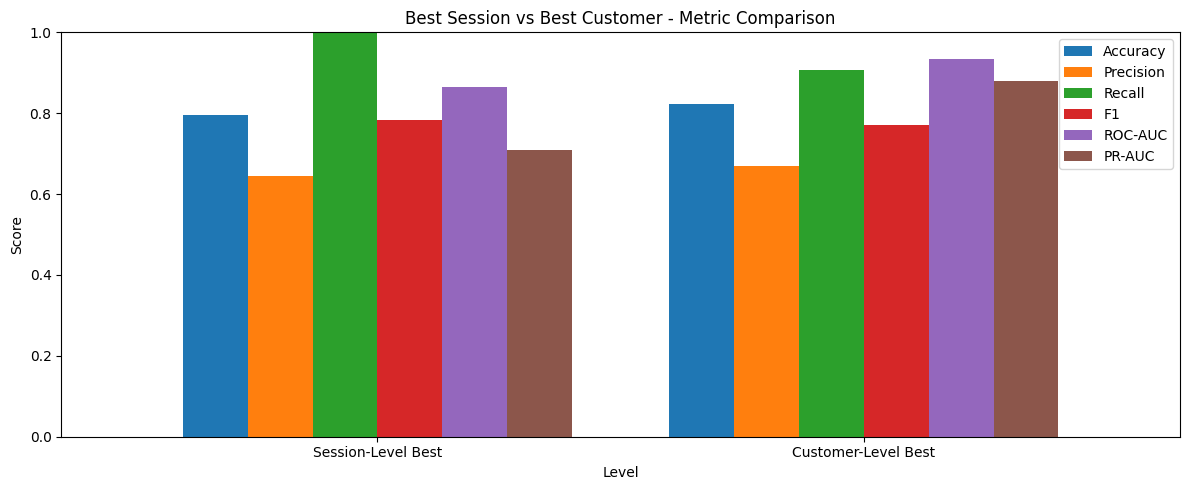

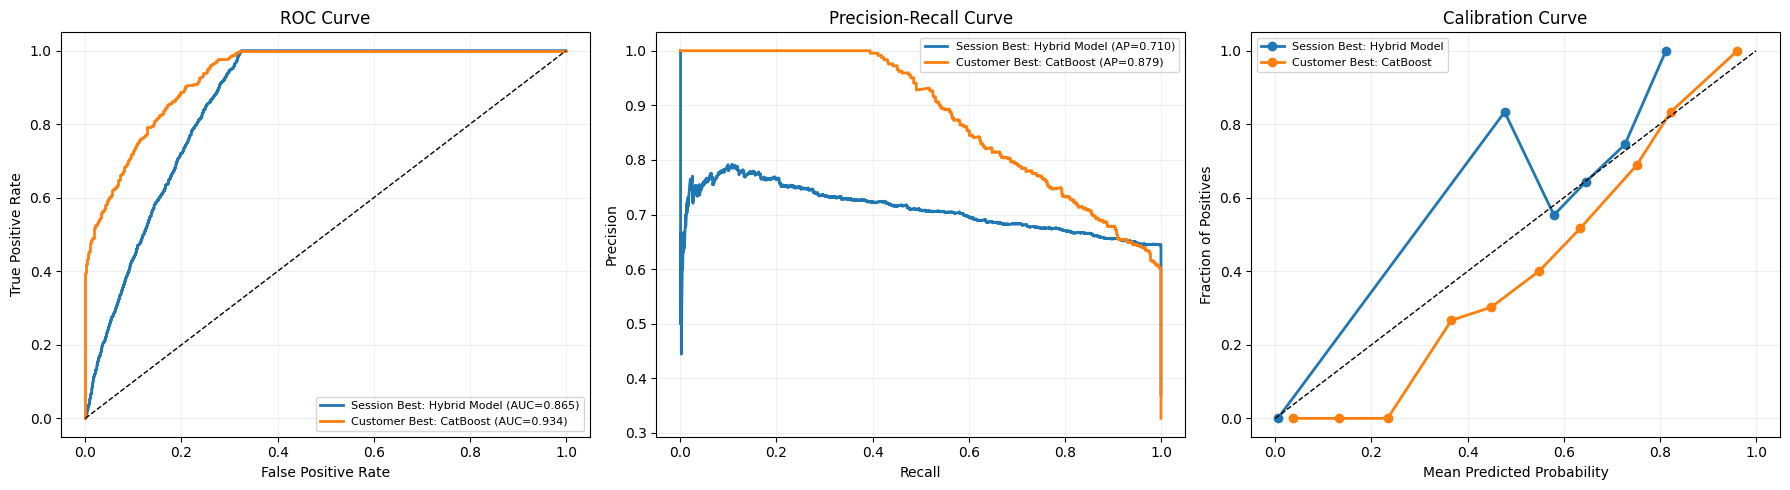

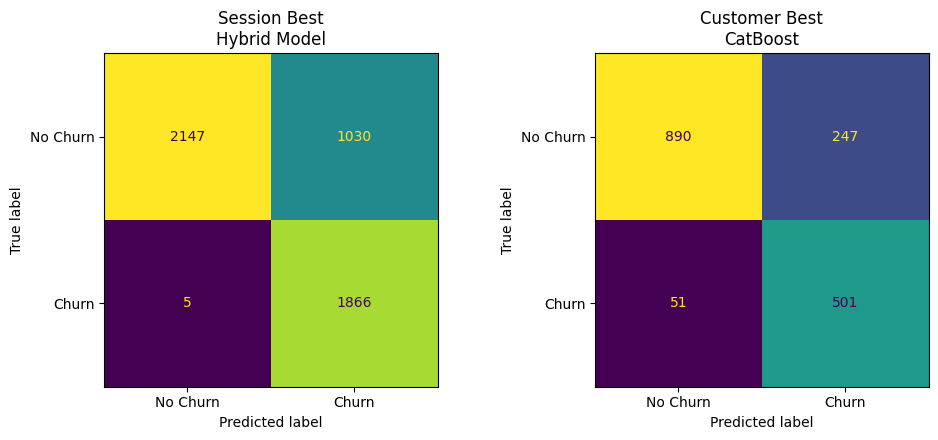

Best Session Model: Hybrid Model
Best Customer Model: CatBoost

Best vs Best Metrics
                            Model  Accuracy  Precision  Recall      F1  \
Level                                                                    
Session-Level Best   Hybrid Model    0.7954     0.6447  0.9979  0.7833   
Customer-Level Best      CatBoost    0.8236     0.6698  0.9076  0.7708   

                     ROC-AUC  PR-AUC  Brier Score  
Level                                              
Session-Level Best    0.8651  0.7080       0.1293  
Customer-Level Best   0.9344  0.8794       0.1041  


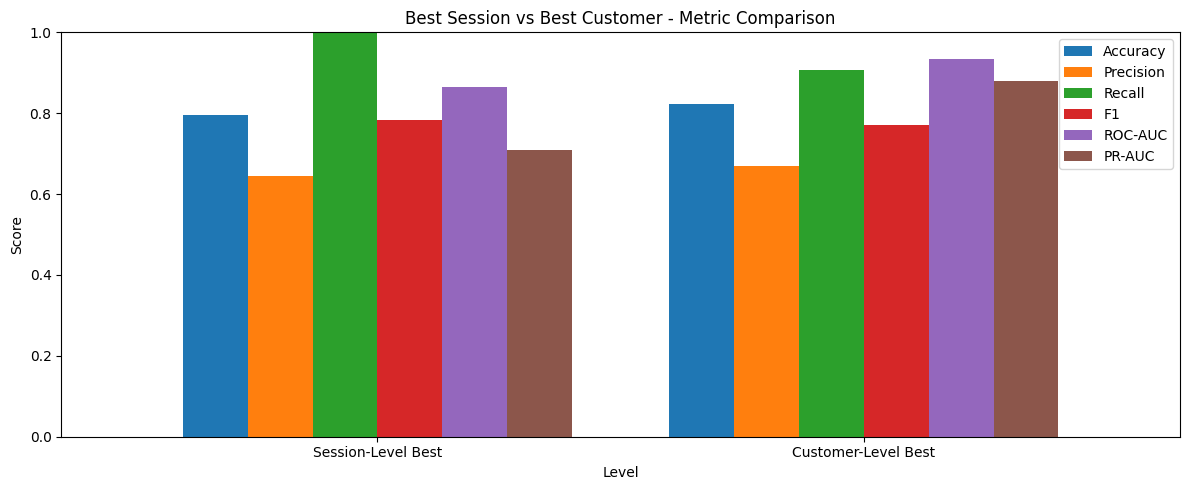

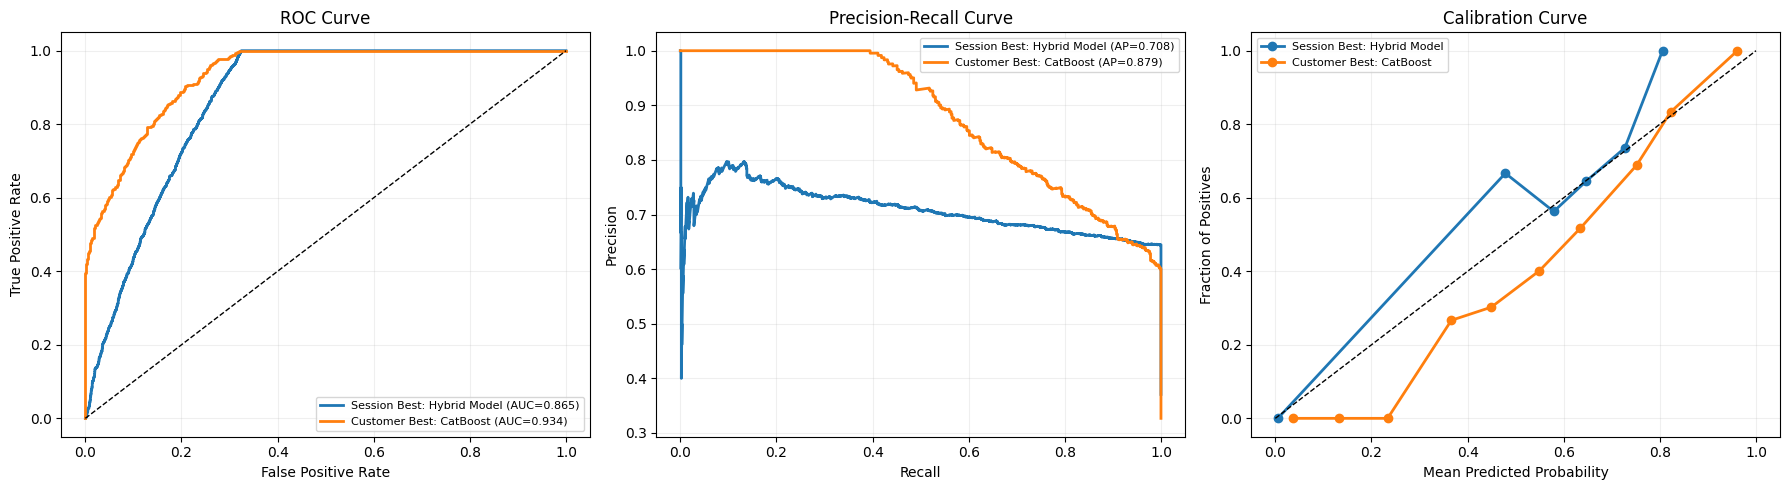

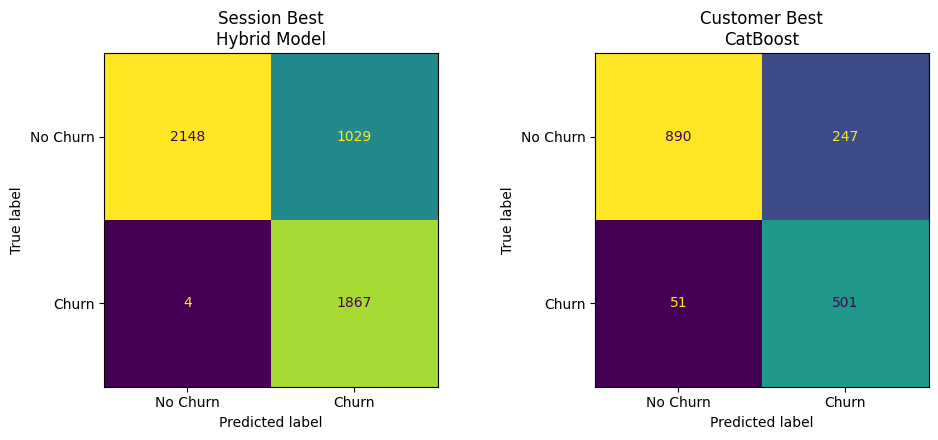

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# -----------------------------
# Helpers
# -----------------------------
def prob_score(model, X):
    if hasattr(model, "predict_proba"):
        s = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        d = model.decision_function(X)
        s = 1 / (1 + np.exp(-d))  # sigmoid transform
    else:
        raise ValueError(f"{type(model).__name__} has no score method")
    return np.clip(np.asarray(s).reshape(-1), 1e-8, 1 - 1e-8)

def pred_label(model, X):
    return np.asarray(model.predict(X)).reshape(-1).astype(int)

def metric_dict(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
        "Brier Score": brier_score_loss(y_true, y_score),
    }

# ============================================================
# 1) Find BEST SESSION-LEVEL model (refit on session feature set)
# ============================================================
session_feature_cols = [
    "device_type", "user_type", "marketing_channel", "product_category",
    "payment_method", "visit_month", "visit_weekday", "visit_season",
    "location", "pages_viewed", "time_on_site_sec", "added_to_cart",
    "discount_percent", "engagement_ratio", "cart_efficiency", "time_per_page"
]

X_session = df[session_feature_cols]
y_session = df["churn"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx_s, te_idx_s = next(gss.split(X_session, y_session, groups=df["customer_id"]))

X_train_s = X_session.iloc[tr_idx_s]
X_test_s = X_session.iloc[te_idx_s]
y_train_s = y_session.iloc[tr_idx_s]
y_test_s = y_session.iloc[te_idx_s]

scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

session_candidates = {}
if "session_models" in globals() and isinstance(session_models, dict) and len(session_models) > 0:
    session_candidates.update(session_models)
else:
    # fallback
    if "models" in globals():
        for k in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
            if k in models:
                session_candidates[k] = models[k]
    if "best_xgb" in globals():
        session_candidates["Tuned XGBoost"] = best_xgb
    if "stack_model" in globals():
        session_candidates["Stacking Model"] = stack_model
    if "hybrid_model" in globals():
        session_candidates["Hybrid Model"] = hybrid_model

if len(session_candidates) == 0:
    raise ValueError("No session-level models found")

session_eval_rows = []
session_fitted = {}

for name, base_model in session_candidates.items():
    m = clone(base_model)
    m.fit(X_train_s_scaled, y_train_s)
    y_pred_s = pred_label(m, X_test_s_scaled)
    y_score_s = prob_score(m, X_test_s_scaled)
    row = metric_dict(y_test_s, y_pred_s, y_score_s)
    row["Model"] = name
    session_eval_rows.append(row)
    session_fitted[name] = {"model": m, "y_pred": y_pred_s, "y_score": y_score_s}

session_eval_df = pd.DataFrame(session_eval_rows).sort_values("F1", ascending=False).reset_index(drop=True)
best_session_name = session_eval_df.iloc[0]["Model"]
best_session_pred = session_fitted[best_session_name]["y_pred"]
best_session_score = session_fitted[best_session_name]["y_score"]

# ============================================================
# 2) Find BEST CUSTOMER-LEVEL model
# ============================================================
if "models_customer" not in globals():
    raise ValueError("models_customer not found")

customer_eval_rows = []
customer_store = {}

# standard customer models
for name, model in models_customer.items():
    y_pred_c = pred_label(model, X_test)
    y_score_c = prob_score(model, X_test)
    row = metric_dict(y_test, y_pred_c, y_score_c)
    row["Model"] = name
    customer_eval_rows.append(row)
    customer_store[name] = {"y_pred": y_pred_c, "y_score": y_score_c}

# CatBoost
if "cat_model" in globals():
    y_pred_cat = pred_label(cat_model, X_test)
    y_score_cat = prob_score(cat_model, X_test)
    row = metric_dict(y_test, y_pred_cat, y_score_cat)
    row["Model"] = "CatBoost"
    customer_eval_rows.append(row)
    customer_store["CatBoost"] = {"y_pred": y_pred_cat, "y_score": y_score_cat}

# Manual Soft Voting
if "final_pred" in globals() and "final_prob" in globals():
    y_pred_sv = np.asarray(final_pred).reshape(-1).astype(int)
    y_score_sv = np.clip(np.asarray(final_prob).reshape(-1), 1e-8, 1 - 1e-8)
    row = metric_dict(y_test, y_pred_sv, y_score_sv)
    row["Model"] = "Soft Voting"
    customer_eval_rows.append(row)
    customer_store["Soft Voting"] = {"y_pred": y_pred_sv, "y_score": y_score_sv}

customer_eval_df = pd.DataFrame(customer_eval_rows).sort_values("F1", ascending=False).reset_index(drop=True)
best_customer_name = customer_eval_df.iloc[0]["Model"]
best_customer_pred = customer_store[best_customer_name]["y_pred"]
best_customer_score = customer_store[best_customer_name]["y_score"]

# ============================================================
# 3) Build best-vs-best table
# ============================================================
best_vs_best = pd.DataFrame([
    {"Level": "Session-Level Best", "Model": best_session_name, **metric_dict(y_test_s, best_session_pred, best_session_score)},
    {"Level": "Customer-Level Best", "Model": best_customer_name, **metric_dict(y_test, best_customer_pred, best_customer_score)}
]).set_index("Level")

print("Best Session Model:", best_session_name)
print("Best Customer Model:", best_customer_name)
print("\nBest vs Best Metrics")
print(best_vs_best.round(4))

# ============================================================
# 4) Plot comparisons
# ============================================================

# 4A: Metrics bar chart
plot_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
ax = best_vs_best[plot_cols].plot(kind="bar", figsize=(12, 5), width=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Best Session vs Best Customer - Metric Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4B: ROC + PR + Calibration curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr_s, tpr_s, _ = roc_curve(y_test_s, best_session_score)
fpr_c, tpr_c, _ = roc_curve(y_test, best_customer_score)
axes[0].plot(fpr_s, tpr_s, lw=2, label=f"Session Best: {best_session_name} (AUC={roc_auc_score(y_test_s, best_session_score):.3f})")
axes[0].plot(fpr_c, tpr_c, lw=2, label=f"Customer Best: {best_customer_name} (AUC={roc_auc_score(y_test, best_customer_score):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# PR
prec_s, rec_s, _ = precision_recall_curve(y_test_s, best_session_score)
prec_c, rec_c, _ = precision_recall_curve(y_test, best_customer_score)
axes[1].plot(rec_s, prec_s, lw=2, label=f"Session Best: {best_session_name} (AP={average_precision_score(y_test_s, best_session_score):.3f})")
axes[1].plot(rec_c, prec_c, lw=2, label=f"Customer Best: {best_customer_name} (AP={average_precision_score(y_test, best_customer_score):.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

# Calibration
frac_s, mean_s = calibration_curve(y_test_s, best_session_score, n_bins=10, strategy="uniform")
frac_c, mean_c = calibration_curve(y_test, best_customer_score, n_bins=10, strategy="uniform")
axes[2].plot(mean_s, frac_s, marker="o", lw=2, label=f"Session Best: {best_session_name}")
axes[2].plot(mean_c, frac_c, marker="o", lw=2, label=f"Customer Best: {best_customer_name}")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_title("Calibration Curve")
axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Fraction of Positives")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 4C: Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

cm_s = confusion_matrix(y_test_s, best_session_pred)
disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_s, display_labels=["No Churn", "Churn"])
disp_s.plot(ax=axes[0], colorbar=False, values_format="d")
axes[0].set_title(f"Session Best\n{best_session_name}")

cm_c = confusion_matrix(y_test, best_customer_pred)
disp_c = ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=["No Churn", "Churn"])
disp_c.plot(ax=axes[1], colorbar=False, values_format="d")
axes[1].set_title(f"Customer Best\n{best_customer_name}")

plt.tight_layout()
plt.show()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# -----------------------------
# Helpers
# -----------------------------
def prob_score(model, X):
    if hasattr(model, "predict_proba"):
        s = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        d = model.decision_function(X)
        s = 1 / (1 + np.exp(-d))  # sigmoid transform
    else:
        raise ValueError(f"{type(model).__name__} has no score method")
    return np.clip(np.asarray(s).reshape(-1), 1e-8, 1 - 1e-8)

def pred_label(model, X):
    return np.asarray(model.predict(X)).reshape(-1).astype(int)

def metric_dict(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score),
        "Brier Score": brier_score_loss(y_true, y_score),
    }

# ============================================================
# 1) Find BEST SESSION-LEVEL model (refit on session feature set)
# ============================================================
session_feature_cols = [
    "device_type", "user_type", "marketing_channel", "product_category",
    "payment_method", "visit_month", "visit_weekday", "visit_season",
    "location", "pages_viewed", "time_on_site_sec", "added_to_cart",
    "discount_percent", "engagement_ratio", "cart_efficiency", "time_per_page"
]

X_session = df[session_feature_cols]
y_session = df["churn"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx_s, te_idx_s = next(gss.split(X_session, y_session, groups=df["customer_id"]))

X_train_s = X_session.iloc[tr_idx_s]
X_test_s = X_session.iloc[te_idx_s]
y_train_s = y_session.iloc[tr_idx_s]
y_test_s = y_session.iloc[te_idx_s]

scaler_s = StandardScaler()
X_train_s_scaled = scaler_s.fit_transform(X_train_s)
X_test_s_scaled = scaler_s.transform(X_test_s)

session_candidates = {}
if "session_models" in globals() and isinstance(session_models, dict) and len(session_models) > 0:
    session_candidates.update(session_models)
else:
    # fallback
    if "models" in globals():
        for k in ["Logistic Regression", "Random Forest", "Gradient Boosting"]:
            if k in models:
                session_candidates[k] = models[k]
    if "best_xgb" in globals():
        session_candidates["Tuned XGBoost"] = best_xgb
    if "stack_model" in globals():
        session_candidates["Stacking Model"] = stack_model
    if "hybrid_model" in globals():
        session_candidates["Hybrid Model"] = hybrid_model

if len(session_candidates) == 0:
    raise ValueError("No session-level models found")

session_eval_rows = []
session_fitted = {}

for name, base_model in session_candidates.items():
    m = clone(base_model)
    m.fit(X_train_s_scaled, y_train_s)
    y_pred_s = pred_label(m, X_test_s_scaled)
    y_score_s = prob_score(m, X_test_s_scaled)
    row = metric_dict(y_test_s, y_pred_s, y_score_s)
    row["Model"] = name
    session_eval_rows.append(row)
    session_fitted[name] = {"model": m, "y_pred": y_pred_s, "y_score": y_score_s}

session_eval_df = pd.DataFrame(session_eval_rows).sort_values("F1", ascending=False).reset_index(drop=True)
best_session_name = session_eval_df.iloc[0]["Model"]
best_session_pred = session_fitted[best_session_name]["y_pred"]
best_session_score = session_fitted[best_session_name]["y_score"]

# ============================================================
# 2) Find BEST CUSTOMER-LEVEL model
# ============================================================
if "models_customer" not in globals():
    raise ValueError("models_customer not found")

customer_eval_rows = []
customer_store = {}

# standard customer models
for name, model in models_customer.items():
    y_pred_c = pred_label(model, X_test)
    y_score_c = prob_score(model, X_test)
    row = metric_dict(y_test, y_pred_c, y_score_c)
    row["Model"] = name
    customer_eval_rows.append(row)
    customer_store[name] = {"y_pred": y_pred_c, "y_score": y_score_c}

# CatBoost
if "cat_model" in globals():
    y_pred_cat = pred_label(cat_model, X_test)
    y_score_cat = prob_score(cat_model, X_test)
    row = metric_dict(y_test, y_pred_cat, y_score_cat)
    row["Model"] = "CatBoost"
    customer_eval_rows.append(row)
    customer_store["CatBoost"] = {"y_pred": y_pred_cat, "y_score": y_score_cat}

# Manual Soft Voting
if "final_pred" in globals() and "final_prob" in globals():
    y_pred_sv = np.asarray(final_pred).reshape(-1).astype(int)
    y_score_sv = np.clip(np.asarray(final_prob).reshape(-1), 1e-8, 1 - 1e-8)
    row = metric_dict(y_test, y_pred_sv, y_score_sv)
    row["Model"] = "Soft Voting"
    customer_eval_rows.append(row)
    customer_store["Soft Voting"] = {"y_pred": y_pred_sv, "y_score": y_score_sv}

customer_eval_df = pd.DataFrame(customer_eval_rows).sort_values("F1", ascending=False).reset_index(drop=True)
best_customer_name = customer_eval_df.iloc[0]["Model"]
best_customer_pred = customer_store[best_customer_name]["y_pred"]
best_customer_score = customer_store[best_customer_name]["y_score"]

# ============================================================
# 3) Build best-vs-best table
# ============================================================
best_vs_best = pd.DataFrame([
    {"Level": "Session-Level Best", "Model": best_session_name, **metric_dict(y_test_s, best_session_pred, best_session_score)},
    {"Level": "Customer-Level Best", "Model": best_customer_name, **metric_dict(y_test, best_customer_pred, best_customer_score)}
]).set_index("Level")

print("Best Session Model:", best_session_name)
print("Best Customer Model:", best_customer_name)
print("\nBest vs Best Metrics")
print(best_vs_best.round(4))

# ============================================================
# 4) Plot comparisons
# ============================================================

# 4A: Metrics bar chart
plot_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
ax = best_vs_best[plot_cols].plot(kind="bar", figsize=(12, 5), width=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Best Session vs Best Customer - Metric Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4B: ROC + PR + Calibration curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr_s, tpr_s, _ = roc_curve(y_test_s, best_session_score)
fpr_c, tpr_c, _ = roc_curve(y_test, best_customer_score)
axes[0].plot(fpr_s, tpr_s, lw=2, label=f"Session Best: {best_session_name} (AUC={roc_auc_score(y_test_s, best_session_score):.3f})")
axes[0].plot(fpr_c, tpr_c, lw=2, label=f"Customer Best: {best_customer_name} (AUC={roc_auc_score(y_test, best_customer_score):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.2)

# PR
prec_s, rec_s, _ = precision_recall_curve(y_test_s, best_session_score)
prec_c, rec_c, _ = precision_recall_curve(y_test, best_customer_score)
axes[1].plot(rec_s, prec_s, lw=2, label=f"Session Best: {best_session_name} (AP={average_precision_score(y_test_s, best_session_score):.3f})")
axes[1].plot(rec_c, prec_c, lw=2, label=f"Customer Best: {best_customer_name} (AP={average_precision_score(y_test, best_customer_score):.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2)

# Calibration
frac_s, mean_s = calibration_curve(y_test_s, best_session_score, n_bins=10, strategy="uniform")
frac_c, mean_c = calibration_curve(y_test, best_customer_score, n_bins=10, strategy="uniform")
axes[2].plot(mean_s, frac_s, marker="o", lw=2, label=f"Session Best: {best_session_name}")
axes[2].plot(mean_c, frac_c, marker="o", lw=2, label=f"Customer Best: {best_customer_name}")
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_title("Calibration Curve")
axes[2].set_xlabel("Mean Predicted Probability")
axes[2].set_ylabel("Fraction of Positives")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 4C: Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

cm_s = confusion_matrix(y_test_s, best_session_pred)
disp_s = ConfusionMatrixDisplay(confusion_matrix=cm_s, display_labels=["No Churn", "Churn"])
disp_s.plot(ax=axes[0], colorbar=False, values_format="d")
axes[0].set_title(f"Session Best\n{best_session_name}")

cm_c = confusion_matrix(y_test, best_customer_pred)
disp_c = ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=["No Churn", "Churn"])
disp_c.plot(ax=axes[1], colorbar=False, values_format="d")
axes[1].set_title(f"Customer Best\n{best_customer_name}")

plt.tight_layout()
plt.show()


SEGMENT-WISE MODEL

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

segment_results = {}

for seg in df['cluster'].unique():
    data = df[df['cluster'] == seg]
    
    X_seg = data[[
        'device_type',
        'user_type',
        'marketing_channel',
        'product_category',
        'payment_method',
        'visit_month',
        'visit_weekday',
        'visit_season',
        'location',
        'pages_viewed',
        'time_on_site_sec',
        'added_to_cart',
        'discount_percent'
    ]]
    
    y_seg = data['churn']
    
    X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )
    
    model = RandomForestClassifier(n_estimators=200)
    model.fit(X_train_seg, y_train_seg)
    
    y_pred_seg = model.predict(X_test_seg)
    
    acc = accuracy_score(y_test_seg, y_pred_seg)
    
    segment_results[seg] = acc
    
    print(f"Cluster {seg} Accuracy: {acc:.4f}")

Cluster 2 Accuracy: 0.7083
Cluster 0 Accuracy: 0.8556
Cluster 1 Accuracy: 0.7573


Cluster 0 Accuracy: 0.8556


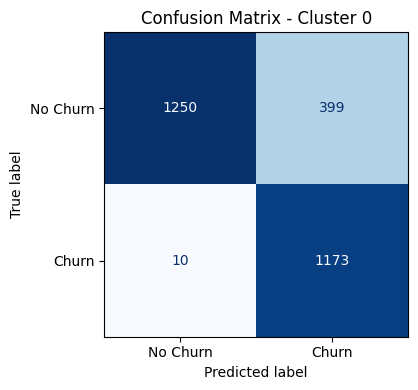

Cluster 1 Accuracy: 0.7649


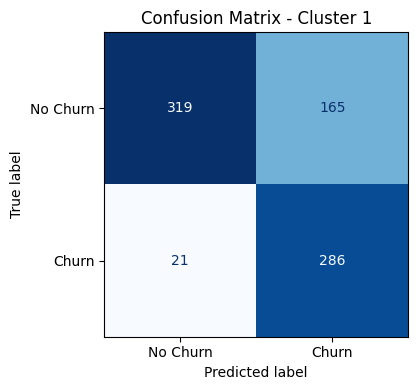

Cluster 2 Accuracy: 0.7025


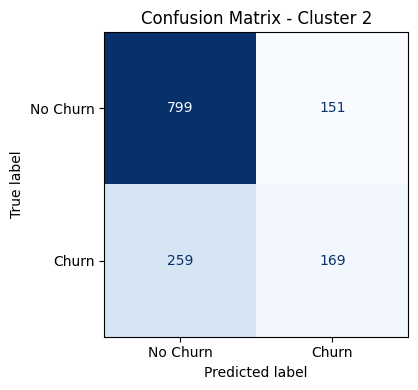

Segment-wise Accuracy: {np.int32(0): 0.8555790960451978, np.int32(1): 0.7648546144121365, np.int32(2): 0.7024673439767779}


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# same feature set used in your segment-wise model
segment_feature_cols = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "payment_method",
    "visit_month",
    "visit_weekday",
    "visit_season",
    "location",
    "pages_viewed",
    "time_on_site_sec",
    "added_to_cart",
    "discount_percent",
]

segment_results = {}

for seg in sorted(df["cluster"].unique()):
    data = df[df["cluster"] == seg]

    X_seg = data[segment_feature_cols]
    y_seg = data["churn"]

    X_train_seg, X_test_seg, y_train_seg, y_test_seg = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )

    # one model per cluster
    model = RandomForestClassifier(n_estimators=200, random_state=42)
    model.fit(X_train_seg, y_train_seg)

    y_pred_seg = model.predict(X_test_seg)

    acc = accuracy_score(y_test_seg, y_pred_seg)
    segment_results[seg] = acc
    print(f"Cluster {seg} Accuracy: {acc:.4f}")

    # confusion matrix for this cluster model
    cm = confusion_matrix(y_test_seg, y_pred_seg, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix - Cluster {seg}")
    plt.tight_layout()
    plt.show()

print("Segment-wise Accuracy:", segment_results)

FEATURE IMPORTANCE


===== SESSION LEVEL FEATURE IMPORTANCE =====
Best Session Model: Random Forest


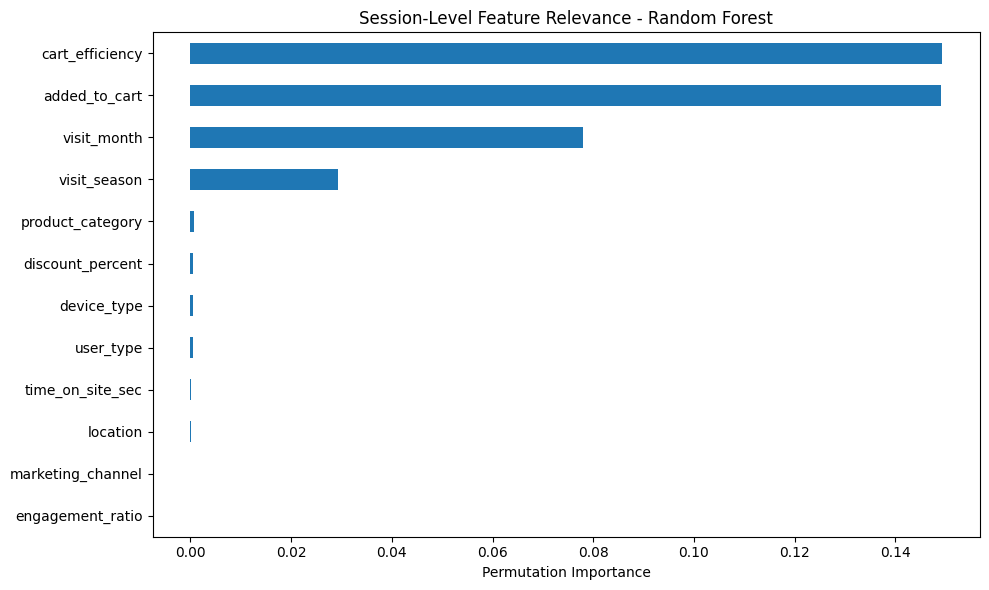


===== CUSTOMER LEVEL FEATURE IMPORTANCE =====
Best Customer Model: CatBoost


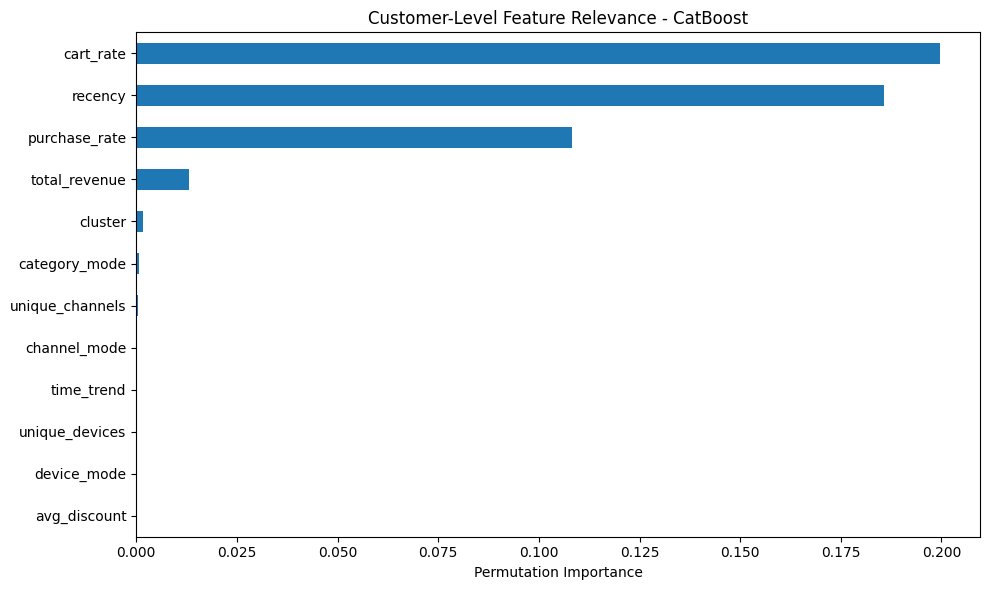

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# ===========================
# HELPER FUNCTION
# ===========================
def plot_feature_relevance(model, X_ref, y_ref, feature_names, title, top_n=12):
    
    result = permutation_importance(
        model,
        X_ref,
        y_ref,
        n_repeats=10,
        random_state=42,
        scoring="f1"
    )

    importances = pd.Series(result.importances_mean, index=feature_names)
    importances = importances.sort_values(ascending=True).tail(top_n)

    plt.figure(figsize=(10, 6))
    importances.plot(kind="barh")
    plt.title(title)
    plt.xlabel("Permutation Importance")
    plt.tight_layout()
    plt.show()


# ===========================
# SESSION LEVEL
# ===========================

print("\n===== SESSION LEVEL FEATURE IMPORTANCE =====")

# 🔥 FIX: ensure correct feature format
X_test_session = pd.DataFrame(X_test_session, columns=session_feature_cols_saved)

# Best model selection
best_session_name = session_metrics_df["F1"].idxmax()
best_session_model = session_models[best_session_name]

print(f"Best Session Model: {best_session_name}")

# Plot
plot_feature_relevance(
    best_session_model,
    X_test_session,
    y_test_session,
    session_feature_cols_saved,
    f"Session-Level Feature Relevance - {best_session_name}"
)


# ===========================
# CUSTOMER LEVEL
# ===========================

print("\n===== CUSTOMER LEVEL FEATURE IMPORTANCE =====")

# Feature columns
customer_feature_cols = customer_df.drop(columns=["customer_id", "churn"]).columns.tolist()

# Combine all models
customer_models_all = dict(models_customer)

# Add CatBoost if available
try:
    customer_models_all["CatBoost"] = cat_model
except:
    print("⚠️ CatBoost not found, skipping...")

# Remove Soft Voting if present
valid_metrics_df = metrics_df.drop(index=["Soft Voting"], errors="ignore")

# Select best model
best_customer_name = valid_metrics_df["F1-score"].idxmax()
best_customer_model = customer_models_all[best_customer_name]

print(f"Best Customer Model: {best_customer_name}")

# Plot
plot_feature_relevance(
    best_customer_model,
    X_test,
    y_test,
    customer_feature_cols,
    f"Customer-Level Feature Relevance - {best_customer_name}"
)

In [75]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

rows = []

# -----------------------------
# Session-level feature importance
# -----------------------------
if "best_session_model" in globals() and "y_test_session" in globals():
    if "session_feature_cols_saved" in globals() and "X_test_session" in globals():
        Xs = pd.DataFrame(X_test_session, columns=session_feature_cols_saved)
        s_features = session_feature_cols_saved
    elif "session_feature_cols" in globals() and "X_test" in globals():
        Xs = pd.DataFrame(X_test, columns=session_feature_cols)
        s_features = session_feature_cols
    else:
        Xs, s_features = None, None

    if Xs is not None:
        s_imp = permutation_importance(
            best_session_model, Xs, y_test_session,
            n_repeats=10, random_state=42, scoring="f1"
        )
        for f, v in zip(s_features, s_imp.importances_mean):
            rows.append({
                "level": "session",
                "model": type(best_session_model).__name__,
                "feature": f,
                "importance": float(v)
            })

# -----------------------------
# Customer-level feature importance
# -----------------------------
if "best_customer_model" in globals() and "X_test" in globals() and "y_test" in globals():
    c_features = (
        customer_feature_cols
        if "customer_feature_cols" in globals()
        else list(X_test.columns) if hasattr(X_test, "columns")
        else [f"f{i}" for i in range(X_test.shape[1])]
    )

    Xc = X_test if hasattr(X_test, "columns") else pd.DataFrame(X_test, columns=c_features)

    c_imp = permutation_importance(
        best_customer_model, Xc, y_test,
        n_repeats=10, random_state=42, scoring="f1"
    )
    for f, v in zip(c_features, c_imp.importances_mean):
        rows.append({
            "level": "customer",
            "model": type(best_customer_model).__name__,
            "feature": f,
            "importance": float(v)
        })

feature_importance_df = pd.DataFrame(rows).sort_values(
    ["level", "importance"], ascending=[True, False]
).reset_index(drop=True)

print("feature_importance_df created:", feature_importance_df.shape)
display(feature_importance_df.head(10))

feature_importance_df created: (39, 4)


,level,model,feature,importance
0,customer,CatBoostClassifier,cart_rate,0.199590
1,customer,CatBoostClassifier,recency,0.185809
2,customer,CatBoostClassifier,purchase_rate,0.108165
3,customer,CatBoostClassifier,total_revenue,0.013200
4,customer,CatBoostClassifier,cluster,0.001762
5,customer,CatBoostClassifier,category_mode,0.000589
6,customer,CatBoostClassifier,unique_channels,0.000388
7,customer,CatBoostClassifier,channel_mode,0.000305
8,customer,CatBoostClassifier,time_trend,0.000296
9,customer,CatBoostClassifier,unique_devices,0.000288


In [78]:
import os
import json
import joblib

os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

# -----------------------------
# Save only 2 final models
# -----------------------------
if "best_session_model" not in globals():
    raise NameError("best_session_model not found. Run session model selection first.")

if "best_customer_model" not in globals():
    raise NameError("best_customer_model not found. Run customer model selection first.")

joblib.dump(best_session_model, "../models/best_session_model.pkl")
joblib.dump(best_customer_model, "../models/best_customer_model.pkl")

# -----------------------------
# Save reports (no segment-wise reports)
# -----------------------------
session_metrics_df.reset_index().rename(columns={"index": "model"}).to_csv("../reports/session_metrics.csv", index=False)
metrics_df.reset_index().rename(columns={"index": "model"}).to_csv("../reports/customer_metrics.csv", index=False)

if "feature_importance_df" in globals():
    feature_importance_df.to_csv("../reports/feature_importance.csv", index=False)

# -----------------------------
# Save feature columns
# -----------------------------
feature_cols_payload = {}

if "session_feature_cols_saved" in globals():
    feature_cols_payload["session_level_features"] = session_feature_cols_saved
elif "session_feature_cols" in globals():
    feature_cols_payload["session_level_features"] = session_feature_cols

if "customer_feature_cols" in globals():
    feature_cols_payload["customer_level_features"] = customer_feature_cols

with open("../reports/feature_cols.json", "w") as f:
    json.dump(feature_cols_payload, f, indent=2)

print("Saved 2 models only: best_session_model and best_customer_model.")

Saved 2 models only: best_session_model and best_customer_model.
